# Green Space, Urban Heat, and Residential Equity in Metropolitan Melbourne
## 1.Iintroduction 
Urban green spaces are a vital component of the city environment, providing people with places for recreation, social interaction, and daily outdoor activities. At the same time, green spaces can help cool local areas by offering shade, increasing evapotranspiration, and reducing the proportion of hard, impermeable surfaces. In large, densely populated urban regions such as the Melbourne metropolitan area, the spatial distribution of green spaces is closely linked to residents' comfort, levels of urban heat exposure, and climate resilience.


However, the benefits of green spaces are not always evenly distributed. Some areas may have abundant parks, open spaces, and vegetation, while others struggle to access sufficient green resources. These disparities become even more pronounced when they overlap with social vulnerability—such as in areas with low income levels, high population density, or higher proportions of elderly and children.

This project investigates the spatial relationships among green spaces, urban thermal environments, and residential equity in the Melbourne metropolitan area. Using Statistical Area 2 (SA2) as the primary analytical unit, it integrates data on open spaces, urban heat conditions, vegetation, and census indicators from the Australian Bureau of Statistics. The analysis aims to examine whether green spaces are spatially equitably distributed, whether they are associated with lower heat exposure risks, and whether socially vulnerable areas are more likely to face both insufficient greenery and higher heat risks. The findings will support the identification of priority areas for future urban greening initiatives, improvements in public open spaces, and climate-resilience planning.areas.

## 2. Research Question

How are green space, urban heat exposure, and residential equity spatially related across Melbourne’s metropol

## 3. study area

The study area is the SA2 analysis area within Metropolitan Melbourne. It contains 360 SA2 units. All environmental and social indicators are aggregated to the SA2 level for comparison, mapping, and priority analysis.and mapping.

In [1]:
# Import libraries and define project paths

from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import seaborn as sns
from IPython.display import display
from rasterstats import zonal_stats

warnings.filterwarnings("ignore", category=FutureWarning)

TARGET_CRS = "EPSG:7855"


def find_project_root(start=Path.cwd()):
    """Locate the project folder containing data/raw."""
    for path in [start, *start.parents]:
        if (path / "data" / "raw").exists():
            return path

    raise FileNotFoundError(
        "Project root folder was not found. "
        "Confirm that the notebook is inside the project directory."
    )


project_dir = find_project_root()
raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"

boundary_dir = raw_dir / "boundary"
census_dir = raw_dir / "census"
open_space_dir = raw_dir / "open_space"
urban_heat_dir = raw_dir / "urban_heat"

processed_dir.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_dir)
print("Raw data folder:", raw_dir)
print("Processed data folder:", processed_dir)


Project directory: C:\Users\15483\Documents\GitHub\geom90006_a4
Raw data folder: C:\Users\15483\Documents\GitHub\geom90006_a4\data\raw
Processed data folder: C:\Users\15483\Documents\GitHub\geom90006_a4\data\processed


In [2]:
# Load main datasets

greater_melb = gpd.read_file(boundary_dir / "greater_melbourne_boundary.gpkg")
sa2_full = gpd.read_file(boundary_dir / "sa2_greater_melbourne.gpkg")

# Final SA2 analysis area
sa2_analysis = gpd.read_file(boundary_dir / "sa2_analysis_area.gpkg")

open_space = gpd.read_file(open_space_dir / "open_space_melbourne.gpkg")
urban_heat = gpd.read_file(urban_heat_dir / "urban_heat.gpkg")

print("Greater Melbourne boundary:", greater_melb.shape)
print("Full SA2 boundary:", sa2_full.shape)
print("Final SA2 analysis area:", sa2_analysis.shape)
print("Open space:", open_space.shape)
print("Urban heat:", urban_heat.shape)

Greater Melbourne boundary: (1, 12)
Full SA2 boundary: (361, 18)
Final SA2 analysis area: (360, 19)
Open space: (38639, 22)
Urban heat: (55603, 20)


In [3]:
# Standardise coordinate reference systems and calculate SA2 area

greater_melb = greater_melb.to_crs(TARGET_CRS)
sa2_full = sa2_full.to_crs(TARGET_CRS)
sa2_analysis = sa2_analysis.to_crs(TARGET_CRS)
open_space = open_space.to_crs(TARGET_CRS)
urban_heat = urban_heat.to_crs(TARGET_CRS)

print("Invalid geometries:")
print("Greater Melbourne boundary:", (~greater_melb.is_valid).sum())
print("Full SA2 boundary:", (~sa2_full.is_valid).sum())
print("Final SA2 analysis area:", (~sa2_analysis.is_valid).sum())
print("Open space:", (~open_space.is_valid).sum())
print("Urban heat:", (~urban_heat.is_valid).sum())

sa2_analysis["area_m2"] = sa2_analysis.geometry.area
sa2_analysis["area_km2"] = sa2_analysis["area_m2"] / 1_000_000

sa2_analysis[
    ["sa2_code", "sa2_name", "area_km2"]
].head()


Invalid geometries:
Greater Melbourne boundary: 0
Full SA2 boundary: 0
Final SA2 analysis area: 0
Open space: 0
Urban heat: 0


,sa2_code,sa2_name,area_km2
0,213051362,Hoppers Crossing - South,7.012411
1,213051368,Werribee - South,114.061560
2,213051467,Werribee - East,7.758551
3,213051468,Werribee - West,59.916045
4,213051579,Manor Lakes - Quandong,14.935574


In [4]:
# Create the SA2 master base dataset

sa2_master = sa2_analysis[
    [
        "sa2_code",
        "sa2_name",
        "area_m2",
        "area_km2",
        "geometry"
    ]
].copy()

sa2_master["sa2_code"] = (
    sa2_master["sa2_code"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

sa2_master.to_file(
    processed_dir / "sa2_master_base.gpkg",
    layer="sa2_master_base",
    driver="GPKG"
)

print("SA2 master base saved successfully.")
print("Number of SA2 areas:", len(sa2_master))

sa2_master.head()


SA2 master base saved successfully.
Number of SA2 areas: 360


,sa2_code,sa2_name,area_m2,area_km2,geometry
0,213051362,Hoppers Crossing - South,7.012411e+06,7.012411,"MULTIPOLYGON (((294653.085 5806028.552, 294645..."
1,213051368,Werribee - South,1.140616e+08,114.061560,"MULTIPOLYGON (((300955.332 5798020.917, 300955..."
2,213051467,Werribee - East,7.758551e+06,7.758551,"MULTIPOLYGON (((292554.398 5804662.406, 292548..."
3,213051468,Werribee - West,5.991604e+07,59.916045,"MULTIPOLYGON (((288867.598 5797885.557, 288870..."
4,213051579,Manor Lakes - Quandong,1.493557e+07,14.935574,"MULTIPOLYGON (((281564.588 5805244.323, 284521..."


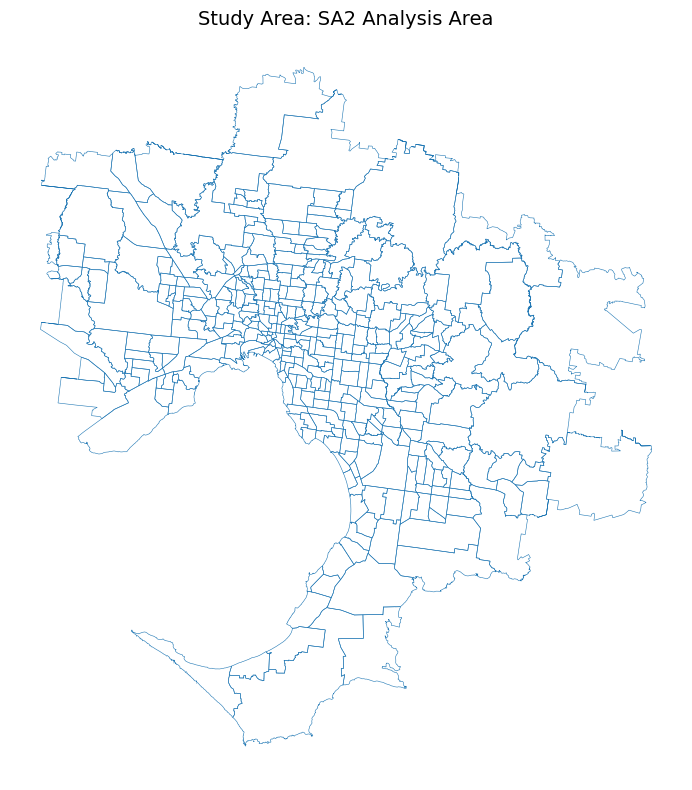

In [5]:
# Map the final SA2 study area

fig, ax = plt.subplots(figsize=(8, 8))

sa2_master.boundary.plot(
    ax=ax,
    linewidth=0.4
)

ax.set_title("Study Area: SA2 Analysis Area", fontsize=14)
ax.set_axis_off()

fig.tight_layout()
plt.show()


The study area used in this project is the SA2 analysis area within Metropolitan Melbourne. It contains 360 SA2 units and provides the common spatial framework for integrating open space, urban heat, and Census-based social equity indicators.

## 4. Data Sources

This project uses four main groups of datasets:

- **SA2 boundary data**: used as the main spatial analysis unit.
- **ABS Census 2021 data**: used to represent population and social equity indicators.
- **VPA Open Space data**: used to measure the distribution of open space across SA2 areas.
- **Urban Heat and Vegetation 2018 data**: used to represent heat exposure and vegetation-related environmenta
## 5. Data preprocessing

The preprocessing steps include:

1. Loading the boundary, Census, open space, and urban heat datasets.
2. Using the SA2 analysis area as the common study area.
3. Reprojecting all spatial datasets to EPSG:7855 for area-based calculation.
4. Checking invalid geometries in the spatial datasets.
5. Calculating the area of each SA2 unit.
6. Creating a master SA2 base dataset for later analysis.

The final SA2 master base contains SA2 code, SA2 name, area, and geometry. It will be used to join green space, urban heat, and Census-based social equity indicators in the following analysis.nalysis. analysis

# 6. Green Space Analysis

This notebook examines the spatial distribution of open space and green space availability across SA2 areas in Greater Melbourne. Two indicators are analysed:

- Open space coverage (%)
- Green space per capita (m²/person)

## 6.1 Calculate Open Space Coverage

The total area of open space within each SA2 region was obtained by overlaying the open space dataset with SA2 boundaries. Open space coverage was calculated as the proportion of open space area relative to the total SA2 area.

In [6]:
# Calculate open space coverage for each SA2 area

green_space_sa2 = sa2_master.copy()
open_space_green = open_space.to_crs(TARGET_CRS).copy()

open_space_overlay = gpd.overlay(
    open_space_green[["geometry"]],
    green_space_sa2[
        ["sa2_code", "sa2_name", "geometry"]
    ],
    how="intersection"
)

open_space_overlay["open_space_area_m2"] = (
    open_space_overlay.geometry.area
)

open_space_summary = (
    open_space_overlay
    .groupby("sa2_code", as_index=False)["open_space_area_m2"]
    .sum()
)

open_space_summary["sa2_code"] = (
    open_space_summary["sa2_code"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

green_space_sa2 = green_space_sa2.merge(
    open_space_summary,
    on="sa2_code",
    how="left",
    validate="one_to_one"
)

green_space_sa2["open_space_area_m2"] = (
    green_space_sa2["open_space_area_m2"]
    .fillna(0)
)

green_space_sa2["open_space_coverage_pct"] = (
    green_space_sa2["open_space_area_m2"]
    / green_space_sa2["area_m2"]
    * 100
)

green_space_sa2[
    [
        "sa2_code",
        "sa2_name",
        "area_m2",
        "open_space_area_m2",
        "open_space_coverage_pct"
    ]
].head()


,sa2_code,sa2_name,area_m2,open_space_area_m2,open_space_coverage_pct
0,213051362,Hoppers Crossing - South,7.012411e+06,8.268239e+05,11.790865
1,213051368,Werribee - South,1.140616e+08,7.032759e+07,61.657575
2,213051467,Werribee - East,7.758551e+06,1.657223e+06,21.359952
3,213051468,Werribee - West,5.991604e+07,2.559582e+07,42.719471
4,213051579,Manor Lakes - Quandong,1.493557e+07,6.630091e+06,44.391269


## 6.2 Open Space Coverage Map

A choropleth map was produced to visualise the spatial distribution of open space coverage across Greater Melbourne.

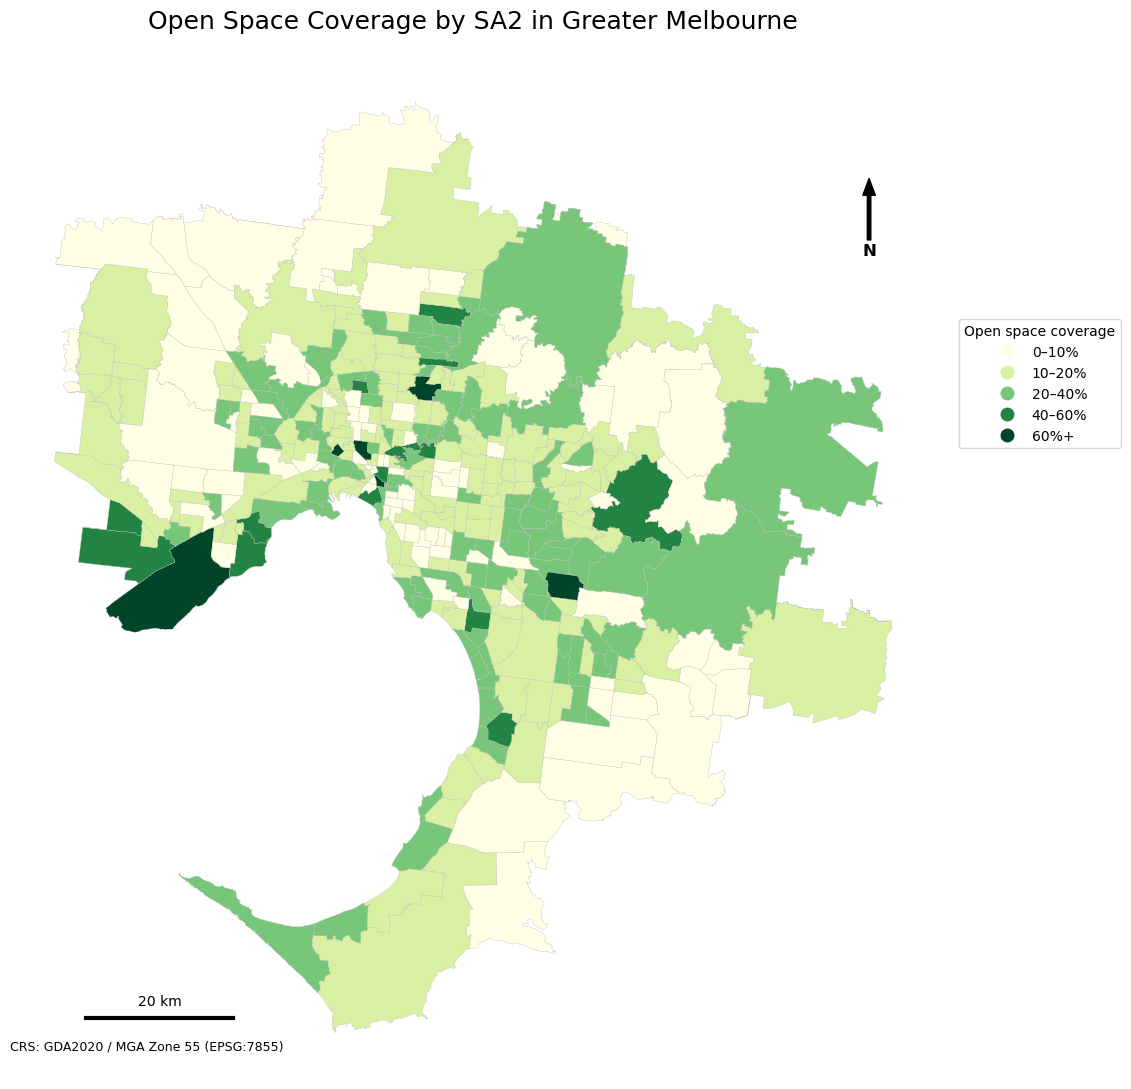

In [7]:
# Classify and map SA2 open space coverage

coverage_bins = [0, 10, 20, 40, 60, np.inf]
coverage_labels = [
    "0–10%",
    "10–20%",
    "20–40%",
    "40–60%",
    "60%+"
]

green_space_sa2["coverage_class"] = pd.cut(
    green_space_sa2["open_space_coverage_pct"],
    bins=coverage_bins,
    labels=coverage_labels,
    include_lowest=True
)

open_space_coverage_fig, open_space_coverage_ax = plt.subplots(
    figsize=(13, 11)
)

green_space_sa2.plot(
    column="coverage_class",
    cmap="YlGn",
    linewidth=0.25,
    edgecolor="#bdbdbd",
    legend=True,
    categorical=True,
    ax=open_space_coverage_ax,
    legend_kwds={
        "title": "Open space coverage",
        "loc": "upper left",
        "bbox_to_anchor": (1.02, 0.75),
        "frameon": True
    }
)

open_space_coverage_ax.set_title(
    "Open Space Coverage by SA2 in Greater Melbourne",
    fontsize=18,
    pad=20
)
open_space_coverage_ax.axis("off")

open_space_coverage_ax.annotate(
    "N",
    xy=(0.93, 0.88),
    xytext=(0.93, 0.81),
    xycoords="axes fraction",
    arrowprops={
        "facecolor": "black",
        "edgecolor": "black",
        "width": 2.5,
        "headwidth": 9
    },
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

x_min, x_max = open_space_coverage_ax.get_xlim()
y_min, y_max = open_space_coverage_ax.get_ylim()

scale_length_m = 20_000
scale_x_start = x_min + (x_max - x_min) * 0.08
scale_y_start = y_min + (y_max - y_min) * 0.06

open_space_coverage_ax.plot(
    [scale_x_start, scale_x_start + scale_length_m],
    [scale_y_start, scale_y_start],
    color="black",
    linewidth=3
)

open_space_coverage_ax.text(
    scale_x_start + scale_length_m / 2,
    scale_y_start + (y_max - y_min) * 0.012,
    "20 km",
    ha="center",
    fontsize=10
)

open_space_coverage_fig.text(
    0.12,
    0.04,
    "CRS: GDA2020 / MGA Zone 55 (EPSG:7855)",
    fontsize=9
)

open_space_coverage_fig.tight_layout()

display(open_space_coverage_fig)
plt.close(open_space_coverage_fig)


### Interpretation

Open space coverage varies considerably across the metropolitan area. Higher percentages are generally observed in outer and peri-urban regions, whereas many inner and middle-ring SA2 areas have relatively limited open space.

---

## 6.3 Summary Statistics

Summary statistics were calculated to provide an overview of the distribution of open space coverage.


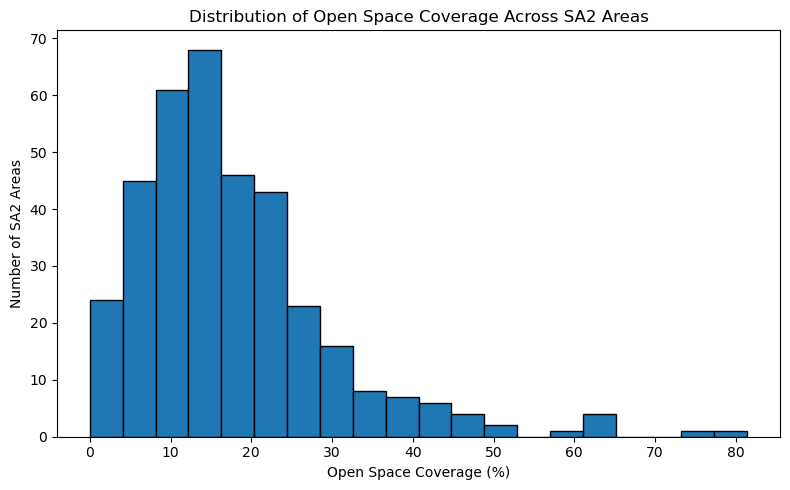

In [8]:
# Plot the distribution of open space coverage

coverage_values = (
    pd.to_numeric(
        green_space_sa2["open_space_coverage_pct"],
        errors="coerce"
    )
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    coverage_values,
    bins=20,
    edgecolor="black"
)

ax.set_xlabel("Open Space Coverage (%)")
ax.set_ylabel("Number of SA2 Areas")
ax.set_title("Distribution of Open Space Coverage Across SA2 Areas")

fig.tight_layout()
plt.show()


## 6.4 Top and Bottom 10 Areas by Open Space Coverage

The highest and lowest ranked SA2 areas were identified to highlight spatial differences.

In [9]:
# Summarise open space coverage and identify the highest-ranked SA2 areas

coverage_summary = (
    green_space_sa2[
        ["sa2_name", "open_space_coverage_pct"]
    ]
    .dropna(subset=["sa2_name", "open_space_coverage_pct"])
    .copy()
)

summary_stats = coverage_summary[
    "open_space_coverage_pct"
].describe()

print("Summary statistics for open space coverage:")
display(
    summary_stats.to_frame(
        name="Open Space Coverage (%)"
    )
)

top10_coverage = (
    coverage_summary
    .sort_values(
        "open_space_coverage_pct",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 SA2 areas with highest open space coverage:")
display(top10_coverage)


Summary statistics for open space coverage:


,Open Space Coverage (%)
count,360.000000
mean,17.592538
std,12.245214
min,0.000000
25%,9.717249
50%,14.855860
75%,22.454452
max,81.410302


Top 10 SA2 areas with highest open space coverage:


,sa2_name,open_space_coverage_pct
0,Royal Botanic Gardens Victoria,81.410302
1,Flemington Racecourse,74.079449
2,Parkville,62.225407
3,Werribee - South,61.657575
4,Kingsbury,61.616537
5,Endeavour Hills - North,61.567997
6,Mount Dandenong - Olinda,58.446738
7,Clifton Hill - Alphington,52.123445
8,East Melbourne,49.388123
9,Point Cook - East,48.746034


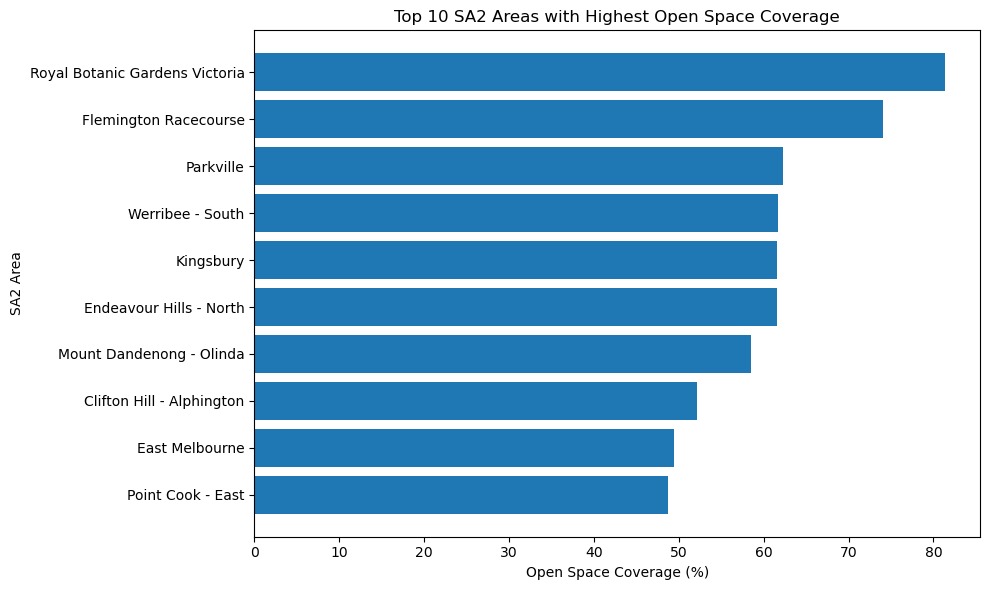

In [10]:
# Bar chart of the ten SA2 areas with the highest coverage

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top10_coverage["sa2_name"],
    top10_coverage["open_space_coverage_pct"]
)

ax.set_xlabel("Open Space Coverage (%)")
ax.set_ylabel("SA2 Area")
ax.set_title("Top 10 SA2 Areas with Highest Open Space Coverage")
ax.invert_yaxis()

fig.tight_layout()
plt.show()


In [11]:
# Identify the ten SA2 areas with the lowest coverage

bottom10_coverage = (
    coverage_summary
    .sort_values(
        "open_space_coverage_pct",
        ascending=True
    )
    .head(10)
    .reset_index(drop=True)
)

print("Bottom 10 SA2 areas with lowest open space coverage:")
display(bottom10_coverage)


Bottom 10 SA2 areas with lowest open space coverage:


,sa2_name,open_space_coverage_pct
0,Essendon Airport,0.000000
1,Riddells Creek,0.000000
2,Moorabbin Airport,0.000000
3,Kinglake,0.004033
4,Gisborne,0.005637
5,Bacchus Marsh,0.025371
6,Tarneit - North,0.080914
7,Clyde North - South,0.208715
8,Diggers Rest,0.362264
9,Tarneit (West) - Mount Cottrell,0.777223


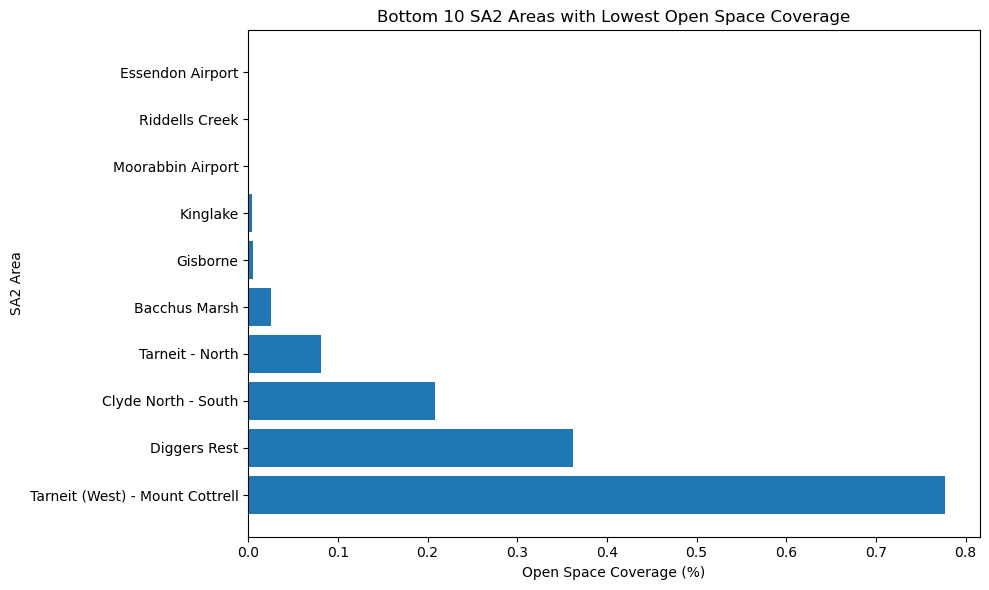

In [12]:
# Bar chart of the ten SA2 areas with the lowest coverage

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    bottom10_coverage["sa2_name"],
    bottom10_coverage["open_space_coverage_pct"]
)

ax.set_xlabel("Open Space Coverage (%)")
ax.set_ylabel("SA2 Area")
ax.set_title("Bottom 10 SA2 Areas with Lowest Open Space Coverage")
ax.invert_yaxis()

fig.tight_layout()
plt.show()


### Interpretation

Areas with the highest coverage are generally characterised by large reserves and lower development intensity. In contrast, highly urbanised areas exhibit much lower proportions of open space.


## 6.5 Calculate Green Space per Capita

Population data from the 2021 Census were merged with the open space dataset. Green space availability per resident was calculated as:

In [13]:
# Load population data and calculate open space per capita

g01 = pd.read_csv(
    census_dir / "2021Census_G01_VIC_SA2.csv",
    low_memory=False
)

population_sa2 = g01[
    ["SA2_CODE_2021", "Tot_P_P"]
].copy()

population_sa2["SA2_CODE_2021"] = (
    population_sa2["SA2_CODE_2021"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

population_sa2["Tot_P_P"] = pd.to_numeric(
    population_sa2["Tot_P_P"],
    errors="coerce"
)

population_sa2 = population_sa2.drop_duplicates(
    subset="SA2_CODE_2021"
)

green_space_population = green_space_sa2.merge(
    population_sa2,
    left_on="sa2_code",
    right_on="SA2_CODE_2021",
    how="left",
    validate="one_to_one"
)

green_space_population["green_space_per_capita_m2"] = (
    green_space_population["open_space_area_m2"]
    / green_space_population["Tot_P_P"]
).where(
    green_space_population["Tot_P_P"] > 0
)

green_space_population["green_space_per_capita_m2"] = (
    green_space_population["green_space_per_capita_m2"]
    .replace([np.inf, -np.inf], np.nan)
)

green_space_population = green_space_population.drop(
    columns="SA2_CODE_2021",
    errors="ignore"
)

print(
    "SA2 areas with missing population values:",
    green_space_population["Tot_P_P"].isna().sum()
)
print(
    "Valid per-capita values:",
    green_space_population[
        "green_space_per_capita_m2"
    ].notna().sum()
)

green_space_population[
    [
        "sa2_code",
        "sa2_name",
        "Tot_P_P",
        "open_space_area_m2",
        "open_space_coverage_pct",
        "green_space_per_capita_m2"
    ]
].head(10)


SA2 areas with missing population values: 0
Valid per-capita values: 358


,sa2_code,sa2_name,Tot_P_P,open_space_area_m2,open_space_coverage_pct,green_space_per_capita_m2
0,213051362,Hoppers Crossing - South,18772,8.268239e+05,11.790865,44.045596
1,213051368,Werribee - South,16810,7.032759e+07,61.657575,4183.675934
2,213051467,Werribee - East,19010,1.657223e+06,21.359952,87.176370
3,213051468,Werribee - West,22341,2.559582e+07,42.719471,1145.688078
4,213051579,Manor Lakes - Quandong,10616,6.630091e+06,44.391269,624.537583
5,213051581,Point Cook - North West,9565,4.324937e+05,14.719077,45.216277
6,213051582,Tarneit (West) - Mount Cottrell,10132,2.853654e+05,0.777223,28.164763
7,213051583,Tarneit - Central,28116,1.142977e+06,14.354930,40.652198
8,213051584,Tarneit - North,7197,1.161021e+04,0.080914,1.613201
9,213051585,Tarneit - South,11182,4.527715e+05,14.460548,40.491106


## 6.6 Green Space per Capita Map

A classified map was generated to show spatial differences in green space availability per resident.

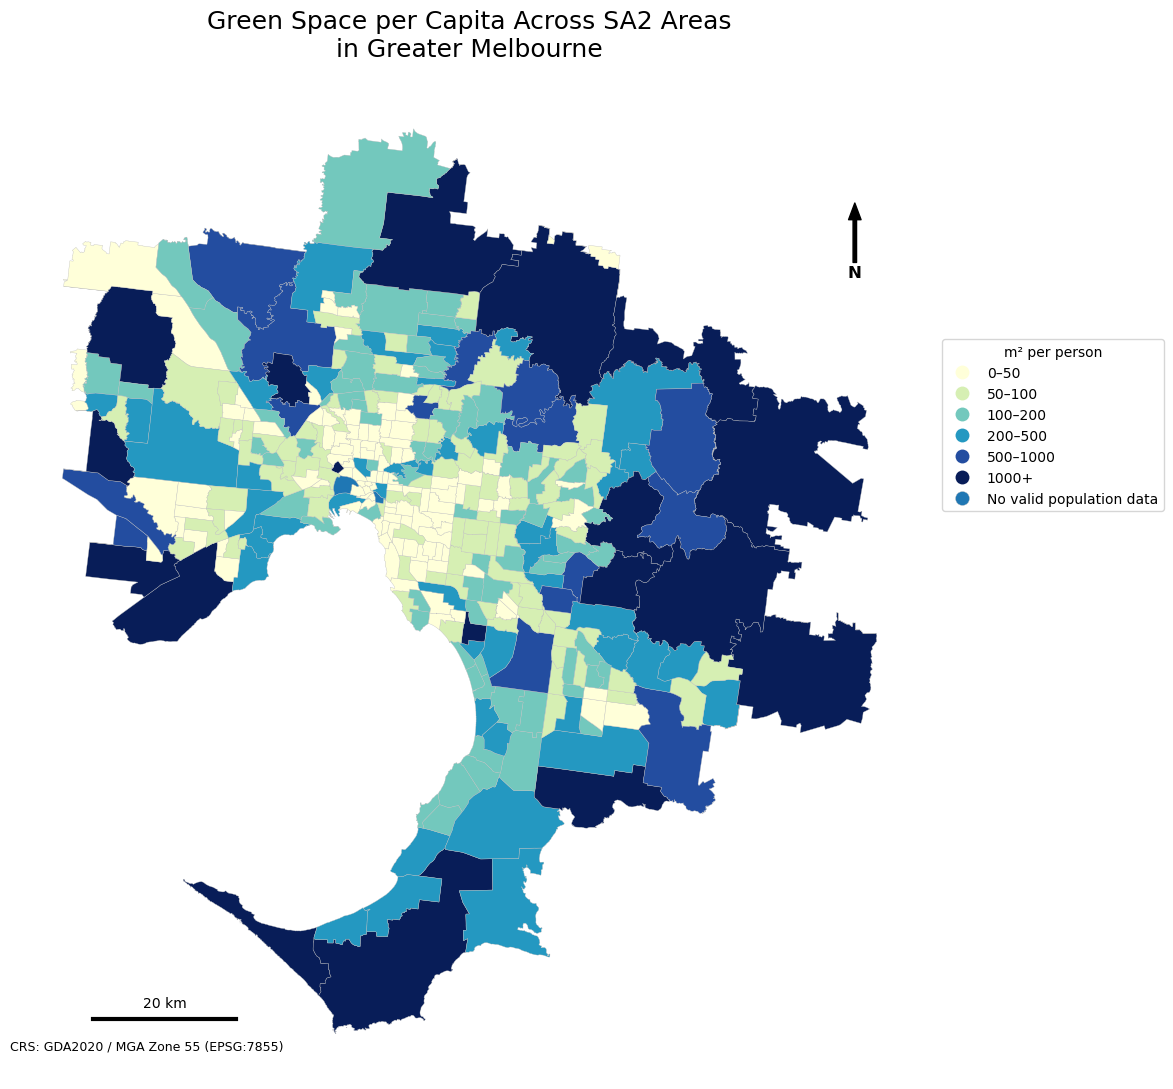

In [14]:
# Map green space per capita using classified values

per_capita_map = green_space_population.to_crs(TARGET_CRS).copy()

per_capita_bins = [
    0,
    50,
    100,
    200,
    500,
    1000,
    np.inf
]

per_capita_labels = [
    "0–50",
    "50–100",
    "100–200",
    "200–500",
    "500–1000",
    "1000+"
]

per_capita_map["per_capita_class"] = pd.cut(
    per_capita_map["green_space_per_capita_m2"],
    bins=per_capita_bins,
    labels=per_capita_labels,
    include_lowest=True
)

fig, ax = plt.subplots(figsize=(13, 11))

per_capita_map.plot(
    column="per_capita_class",
    cmap="YlGnBu",
    categorical=True,
    legend=True,
    linewidth=0.25,
    edgecolor="#bdbdbd",
    ax=ax,
    legend_kwds={
        "title": "m² per person",
        "loc": "upper left",
        "bbox_to_anchor": (1.02, 0.75),
        "frameon": True
    },
    missing_kwds={
        "label": "No valid population data"
    }
)

ax.set_title(
    "Green Space per Capita Across SA2 Areas\nin Greater Melbourne",
    fontsize=18,
    pad=20
)
ax.axis("off")

ax.annotate(
    "N",
    xy=(0.93, 0.88),
    xytext=(0.93, 0.81),
    xycoords="axes fraction",
    arrowprops={
        "facecolor": "black",
        "edgecolor": "black",
        "width": 2.5,
        "headwidth": 9
    },
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold"
)

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

scale_length_m = 20_000
scale_x_start = x_min + (x_max - x_min) * 0.08
scale_y_start = y_min + (y_max - y_min) * 0.06

ax.plot(
    [scale_x_start, scale_x_start + scale_length_m],
    [scale_y_start, scale_y_start],
    color="black",
    linewidth=3
)

ax.text(
    scale_x_start + scale_length_m / 2,
    scale_y_start + (y_max - y_min) * 0.012,
    "20 km",
    ha="center",
    fontsize=10
)

fig.text(
    0.10,
    0.04,
    "CRS: GDA2020 / MGA Zone 55 (EPSG:7855)",
    fontsize=9
)

fig.tight_layout()
plt.show()


### Interpretation

Outer metropolitan areas generally provide substantially more green space per person than densely populated inner-city areas.


## 6.7 Top and Bottom 10 Areas by Green Space per Capita

The highest and lowest ranked SA2 regions were identified.

In [15]:
# Rank SA2 areas by green space per capita

per_capita_valid = (
    green_space_population[
        [
            "sa2_name",
            "Tot_P_P",
            "green_space_per_capita_m2"
        ]
    ]
    .dropna(subset=["green_space_per_capita_m2"])
    .copy()
)

top10_per_capita = (
    per_capita_valid
    .sort_values(
        "green_space_per_capita_m2",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

print("Top 10 SA2 areas by green space per capita:")
display(top10_per_capita)

bottom10_per_capita = (
    per_capita_valid
    .sort_values(
        "green_space_per_capita_m2",
        ascending=True
    )
    .head(10)
    .reset_index(drop=True)
)

print("Bottom 10 SA2 areas by green space per capita:")
display(bottom10_per_capita)


Top 10 SA2 areas by green space per capita:


,sa2_name,Tot_P_P,green_space_per_capita_m2
0,Braeside,31,135163.308572
1,Panton Hill - St Andrews,5091,17914.959609
2,Flemington Racecourse,77,16444.744152
3,Melbourne Airport,126,7781.105725
4,Flinders,5995,6555.485013
5,Yarra Valley,16799,6234.455851
6,Mount Dandenong - Olinda,9706,4930.298159
7,Werribee - South,16810,4183.675934
8,Whittlesea,10661,4058.982742
9,Bunyip - Garfield,9868,2969.238530


Bottom 10 SA2 areas by green space per capita:


,sa2_name,Tot_P_P,green_space_per_capita_m2
0,Moorabbin Airport,26,0.000000
1,Essendon Airport,13,0.000000
2,Riddells Creek,4457,0.000000
3,Romsey,10765,0.000037
4,Kinglake,4204,0.089716
5,Bacchus Marsh,24717,0.128794
6,Gisborne,14222,0.320284
7,Melbourne CBD - East,9848,1.033957
8,Tarneit - North,7197,1.613201
9,Seddon - Kingsville,9247,2.379882


## 6.8 Discussion

The analysis demonstrates substantial spatial inequalities in both open space coverage and green space availability per capita across Greater Melbourne.

Outer and peri-urban SA2s generally contain larger amounts of open land and therefore provide more green space per resident. In contrast, densely developed inner metropolitan areas tend to have lower values for both indicators.

These findings suggest that considering population distribution is essential when evaluating access to green space. Future analyses could incorporate social vulnerability indicators to further investigate issues of environmental equity.

## 7. Green Space and Urban Heat Analysis

This section analyses the relationship between open space distribution and urban heat exposure across the SA2 analysis area. Open space coverage and urban heat indicators are aggregated to the SA2 level and then compared using maps, summary statistics, and correlation analysis.

### 7.1 Exploratory Spatial Data Analysis (ESDA)

This section presents the exploratory spatial data analysis of the main environmental and social variables used in the project. 

Urban heat is one of the most significant environmental challenges facing contemporary cities. Green infrastructure, particularly public open space and tree density, have been widely recognised as an effective strategy for mitigating urban heat. This analysis investigates the relationship between open space coverage and urban heat intensity across Greater Melbourne using spatial analytical techniques

#### 7.1.1 Summary Statistics of Green Space and Urban Heat Indicators

The completed Q2 dataset contains SA2-level indicators for green space coverage, open space area, urban heat, and tree density. This section summarises the distribution of these indicators before further spatial analysis.

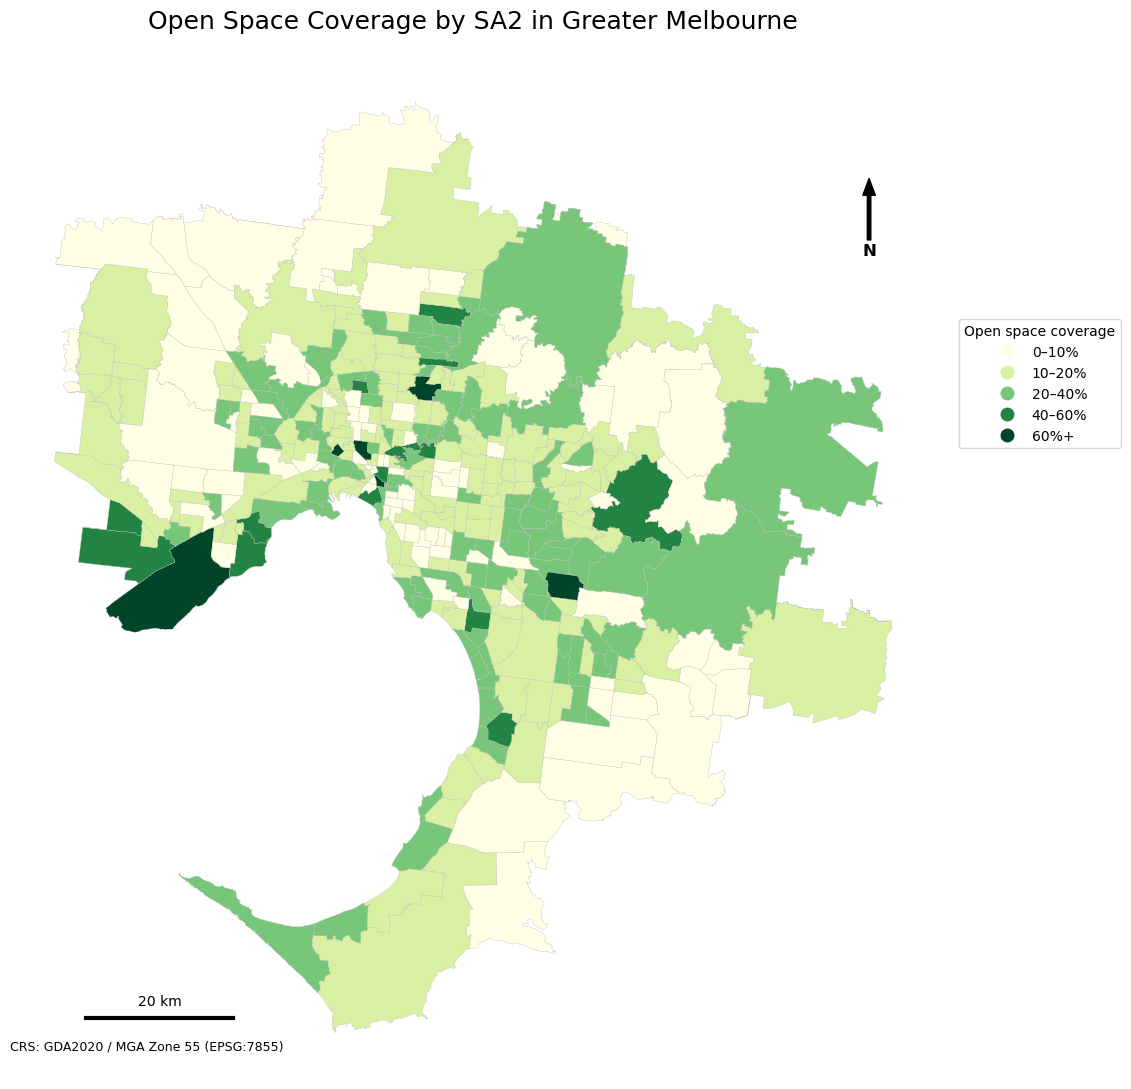

In [16]:
# Reuse the open space coverage map produced in Section 6

if "open_space_coverage_fig" not in globals():
    raise RuntimeError(
        "The open space coverage figure is unavailable. "
        "Run the mapping cell in Section 6 before continuing."
    )

display(open_space_coverage_fig)


## Interpretation

This map presents the spatial distribution of open space coverage across SA2 areas in Greater Melbourne. The results indicate substantial variation in the proportion of land allocated to open space throughout the metropolitan region.

Higher open space coverage appears in several outer metropolitan and peripheral areas, while many inner and middle-ring suburbs display lower proportions. This pattern may be associated with differences in development intensity, land use allocation, and the availability of large public reserves.

In relation to the research question, the findings suggest that green space is not evenly distributed across Greater Melbourne. Although this map focuses only on spatial coverage, it provides an initial indication of potential inequality in environmental amenity and accessibility. Future analysis may incorporate population data to evaluate green space per capita and better assess distribution equity.

### Open Space Coverage Data

Open space coverage was calculated once in Section 6. The prepared Q2 dataset is used below for the urban heat analysis, avoiding repeated spatial overlay and area calculations.


In [17]:
# Load and standardise the prepared Q2 environmental dataset

q2_path = processed_dir / "q2_green_heat_with_tree_count.gpkg"
q2 = gpd.read_file(q2_path)

rename_map = {}

if (
    "coverage" in q2.columns
    and "open_space_coverage_pct" not in q2.columns
):
    rename_map["coverage"] = "open_space_coverage_pct"

if (
    "open_area" in q2.columns
    and "open_space_area_m2" not in q2.columns
):
    rename_map["open_area"] = "open_space_area_m2"

q2 = q2.rename(columns=rename_map)

required_q2_fields = {
    "sa2_code",
    "sa2_name",
    "tree_count",
    "tree_density",
    "open_space_coverage_pct",
    "open_space_area_m2",
    "UHI18_M",
    "geometry"
}

missing_q2_fields = required_q2_fields.difference(q2.columns)

if missing_q2_fields:
    raise KeyError(
        "The prepared Q2 dataset is missing required fields: "
        f"{sorted(missing_q2_fields)}"
    )

q2["sa2_code"] = (
    q2["sa2_code"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

for field in [
    "tree_count",
    "tree_density",
    "open_space_coverage_pct",
    "open_space_area_m2",
    "UHI18_M"
]:
    q2[field] = pd.to_numeric(
        q2[field],
        errors="coerce"
    )

print("Prepared Q2 dataset:", q2.shape)

q2.head()


Prepared Q2 dataset: (257, 9)


,sa2_code,sa2_name,open_space_coverage_pct,open_space_area_m2,UHI18_M,tree_density,area_km2,tree_count,geometry
0,213051362,Hoppers Crossing - South,11.790865,8.268239e+05,8.385504,3050.020758,7.012411,21388,"MULTIPOLYGON (((16104078.525 -4561091.453, 161..."
1,213051368,Werribee - South,61.657575,7.032759e+07,6.900058,456.849792,114.061560,52109,"MULTIPOLYGON (((16111802.697 -4571463.547, 161..."
2,213051467,Werribee - East,21.359952,1.657223e+06,7.630220,3108.183493,7.758551,24115,"MULTIPOLYGON (((16101380.797 -4562759.439, 161..."
3,213051468,Werribee - West,42.719471,2.559582e+07,8.069294,411.225408,59.916045,24639,"MULTIPOLYGON (((16096496.805 -4571250.532, 160..."
4,214021383,Point Nepean,30.647845,2.059349e+07,3.073223,734.992220,67.193908,49387,"MULTIPOLYGON (((16125943.474 -4643363.334, 161..."


In [18]:
q2[
    [
        "tree_count",
        "tree_density",
        "open_space_coverage_pct",
        "open_space_area_m2",
        "UHI18_M"
    ]
].describe()


,tree_count,tree_density,open_space_coverage_pct,open_space_area_m2,UHI18_M
count,257.000000,257.000000,257.000000,2.570000e+02,257.000000
mean,27934.595331,2664.328122,18.383258,4.003341e+06,8.266447
std,27558.029601,1229.724051,12.299425,1.136721e+07,1.828274
min,0.000000,0.000000,0.000000,0.000000e+00,0.029429
25%,12021.000000,1843.198563,10.025083,5.906953e+05,7.517670
50%,20545.000000,2770.123184,16.070639,1.230896e+06,8.398132
75%,30817.000000,3644.043012,22.591331,2.696518e+06,9.373265
max,175247.000000,5041.707885,74.079449,1.047326e+08,11.716022


From the output, we can see that the average number of trees in each SA2 area of ​​Melbourne is approximately 27,935, with an average tree density of 2,664 trees per square kilometer. Extreme values ​​were observed: some SA2 areas had zero trees and a density of zero, while the ecologically best-preserved areas had a total of 175,247 trees and a density of 5,041 trees per square kilometer, indicating an extremely uneven distribution of green canopy resources throughout the city.

We can also see that the distribution of green space in Melbourne is severely polarized, with over 75% of suburbs having a green coverage rate of less than 22.59%, and only a very few marginal eco-zones possessing exceptionally high green coverage. The urban heat island effect is a systemic crisis, with over 75% of the area experiencing an average temperature range exceeding 7.52°C, meaning the vast majority of residents face extremely high heat exposure risks during the summer.

#### 7.1.2 Histogram

* Tree Density Histogram

Number of valid SA2 observations: 257


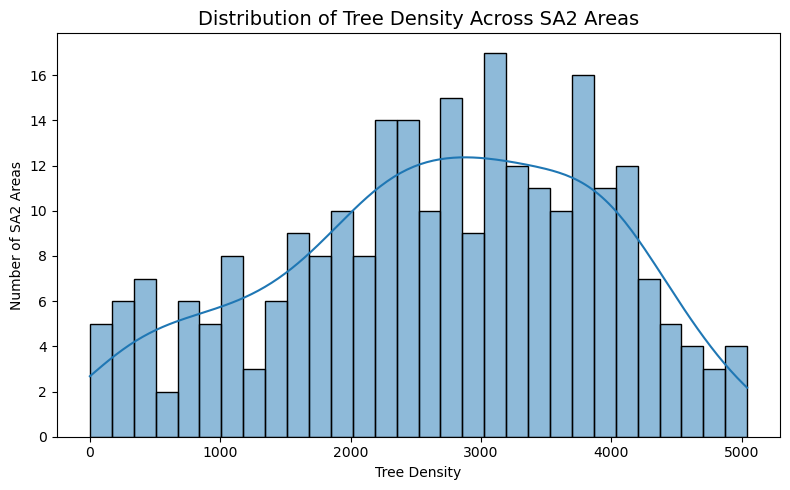

In [19]:
# Prepare and plot valid tree density observations

tree_density_data = (
    q2["tree_density"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

print(
    "Number of valid SA2 observations:",
    len(tree_density_data)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    tree_density_data,
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title(
    "Distribution of Tree Density Across SA2 Areas",
    fontsize=14
)
ax.set_xlabel("Tree Density")
ax.set_ylabel("Number of SA2 Areas")

fig.tight_layout()
plt.show()


The histogram shows that the tree density in the SA2 areas of Melbourne follows an approximately normal distribution, with the data mainly concentrated between 2,000 and 4,000 trees per square kilometer, indicating that most areas have a medium to high level of green coverage.

* Open Space Coverage Histogram

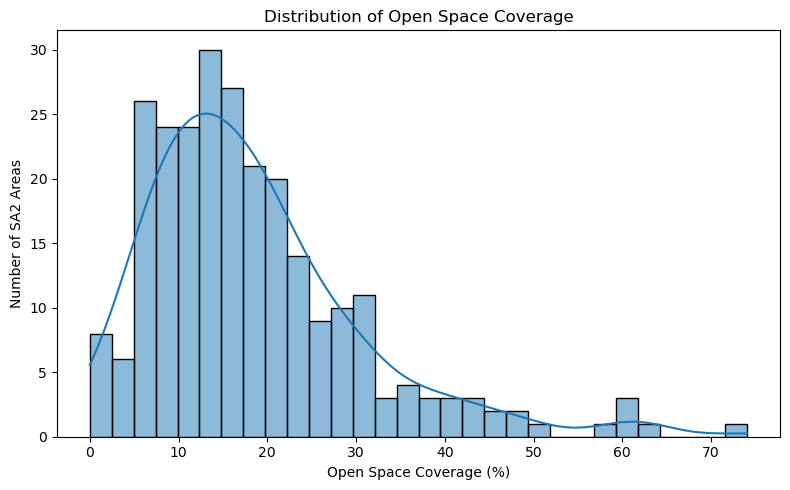

In [20]:
# Plot the distribution of open space coverage

coverage_data = (
    q2["open_space_coverage_pct"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    coverage_data,
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of Open Space Coverage")
ax.set_xlabel("Open Space Coverage (%)")
ax.set_ylabel("Number of SA2 Areas")

fig.tight_layout()
plt.show()


The histogram of open space coverage reveals a highly right-skewed distribution across the SA2 statistical units in Greater Melbourne.

The majority of SA2 areas have relatively low to moderate open space coverage, mainly between 5% and 20%. The peak of the distribution occurs around 12% to 15%, indicating that many SA2 areas have limited open space coverage. The distribution curve also has a long right tail, with some areas reaching over 70% coverage. These high values are likely to represent a small number of low-density fringe areas or areas close to major protected landscapes and national parks, such as the Yarra Range or Dandenong Mountain areas.

* Urban Heat Histogram

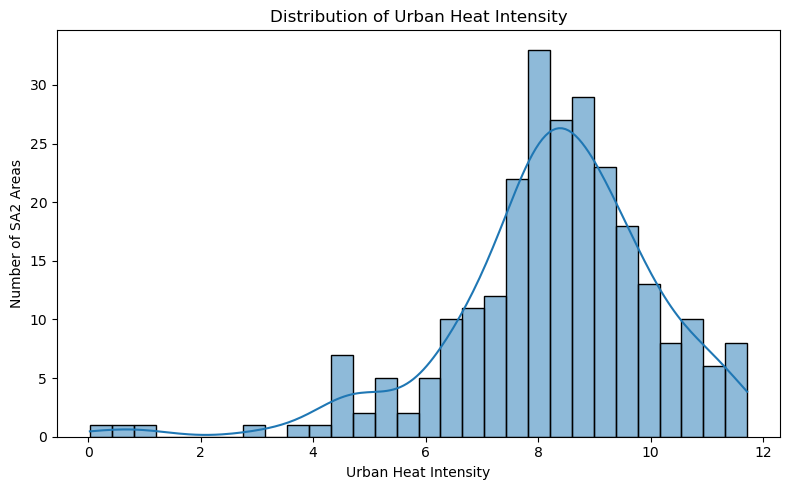

In [21]:
# Plot the distribution of urban heat intensity

uhi_data = (
    q2["UHI18_M"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    uhi_data,
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Distribution of Urban Heat Intensity")
ax.set_xlabel("Urban Heat Intensity")
ax.set_ylabel("Number of SA2 Areas")

fig.tight_layout()
plt.show()


The histogram for Urban Heat Island intensity (UHI18_M) shows a negatively skewed distribution, which contrasts with the open space coverage distribution.

Most SA2 areas are concentrated in the higher UHI range, with the main peak between approximately 7.5 and 9.5. This suggests that urban heat intensity is a common environmental pressure across many residential SA2 areas in Greater Melbourne.

Only a small number of SA2 areas have very low UHI values. These lower-heat areas may correspond to locations with higher open space coverage, larger reserves, or stronger vegetation presence. This pattern provides preliminary evidence that areas with more green space may experience relatively lower urban heat intensity.

The contrast between the open space coverage histogram and the urban heat histogram supports further analysis of the relationship between green space and heat exposure.

#### 7.1.3 Pivot Tables

In [22]:
# Top 10 hottest SA2 areas

pivot_heat = (
    q2[["sa2_name", "UHI18_M"]]
    .sort_values("UHI18_M", ascending=False)
    .head(10)
)

pivot_heat

,sa2_name,UHI18_M
43,Burnside Heights,11.716022
208,Cranbourne,11.665816
40,Sydenham,11.574009
100,Cairnlea,11.566726
245,Narre Warren - North East,11.466223
7,Melton West,11.451552
37,Delahey,11.409298
111,Burnside,11.348166
124,Moorabbin Airport,11.302094
28,Essendon Airport,11.219677


The top 10 hottest SA2 areas are mainly concentrated in western and south-eastern parts of Greater Melbourne, including areas such as Burnside Heights, Sydenham, Cairnlea, Melton West, Cranbourne and Narre Warren. These areas show relatively high urban heat intensity values compared with other SA2 areas.

Several of these areas are rapidly developing outer or middle suburban areas. This result provides useful evidence for the later equity analysis, as it helps identify whether areas with stronger heat exposure also overlap with socially vulnerable communities.

In [23]:
# Compare average urban heat across tree density quintiles

tree_density_labels = [
    "Very low",
    "Low",
    "Medium",
    "High",
    "Very high"
]

q2["tree_density_group"] = pd.qcut(
    q2["tree_density"].rank(method="first"),
    q=5,
    labels=tree_density_labels
)

pivot_tree_density = pd.pivot_table(
    q2,
    values="UHI18_M",
    index="tree_density_group",
    aggfunc="mean",
    observed=False
)

pivot_tree_density


,UHI18_M
tree_density_group,
Very low,7.676172
Low,8.951472
Medium,8.614757
High,8.369604
Very high,7.742087


Across the tree density groups, the average urban heat intensity remains relatively high, but it fluctuates across the groups rather than showing a simple linear decline. This suggests that tree density alone may not fully explain urban heat variation across SA2 areas.

The result indicates that the relationship between tree density and heat exposure is likely affected by other factors, such as land use, built-up density, impervious surfaces, and the spatial arrangement of vegetation.

In [24]:
# Compare average urban heat across open space coverage quintiles

coverage_group_labels = [
    "Very low",
    "Low",
    "Medium",
    "High",
    "Very high"
]

q2["coverage_group"] = pd.qcut(
    q2["open_space_coverage_pct"].rank(method="first"),
    q=5,
    labels=coverage_group_labels
)

pivot_coverage = pd.pivot_table(
    q2,
    values="UHI18_M",
    index="coverage_group",
    aggfunc="mean",
    observed=False
)

pivot_coverage


,UHI18_M
coverage_group,
Very low,8.209160
Low,8.249160
Medium,8.365996
High,8.143713
Very high,8.363429


Across the open space coverage groups, the average urban heat intensity remains within a relatively narrow range. The relationship is not a simple linear pattern where higher open space coverage always corresponds to lower heat intensity.

This suggests that urban heat in Greater Melbourne is influenced by broader spatial and built-environment factors. While open space can provide local cooling benefits, green space coverage alone may not be sufficient to explain all variation in urban heat intensity. A more complete interpretation needs to consider tree density, land surface characteristics, urban form, and social vulnerability together.

#### 7.1.4 Spatial Comparison Map

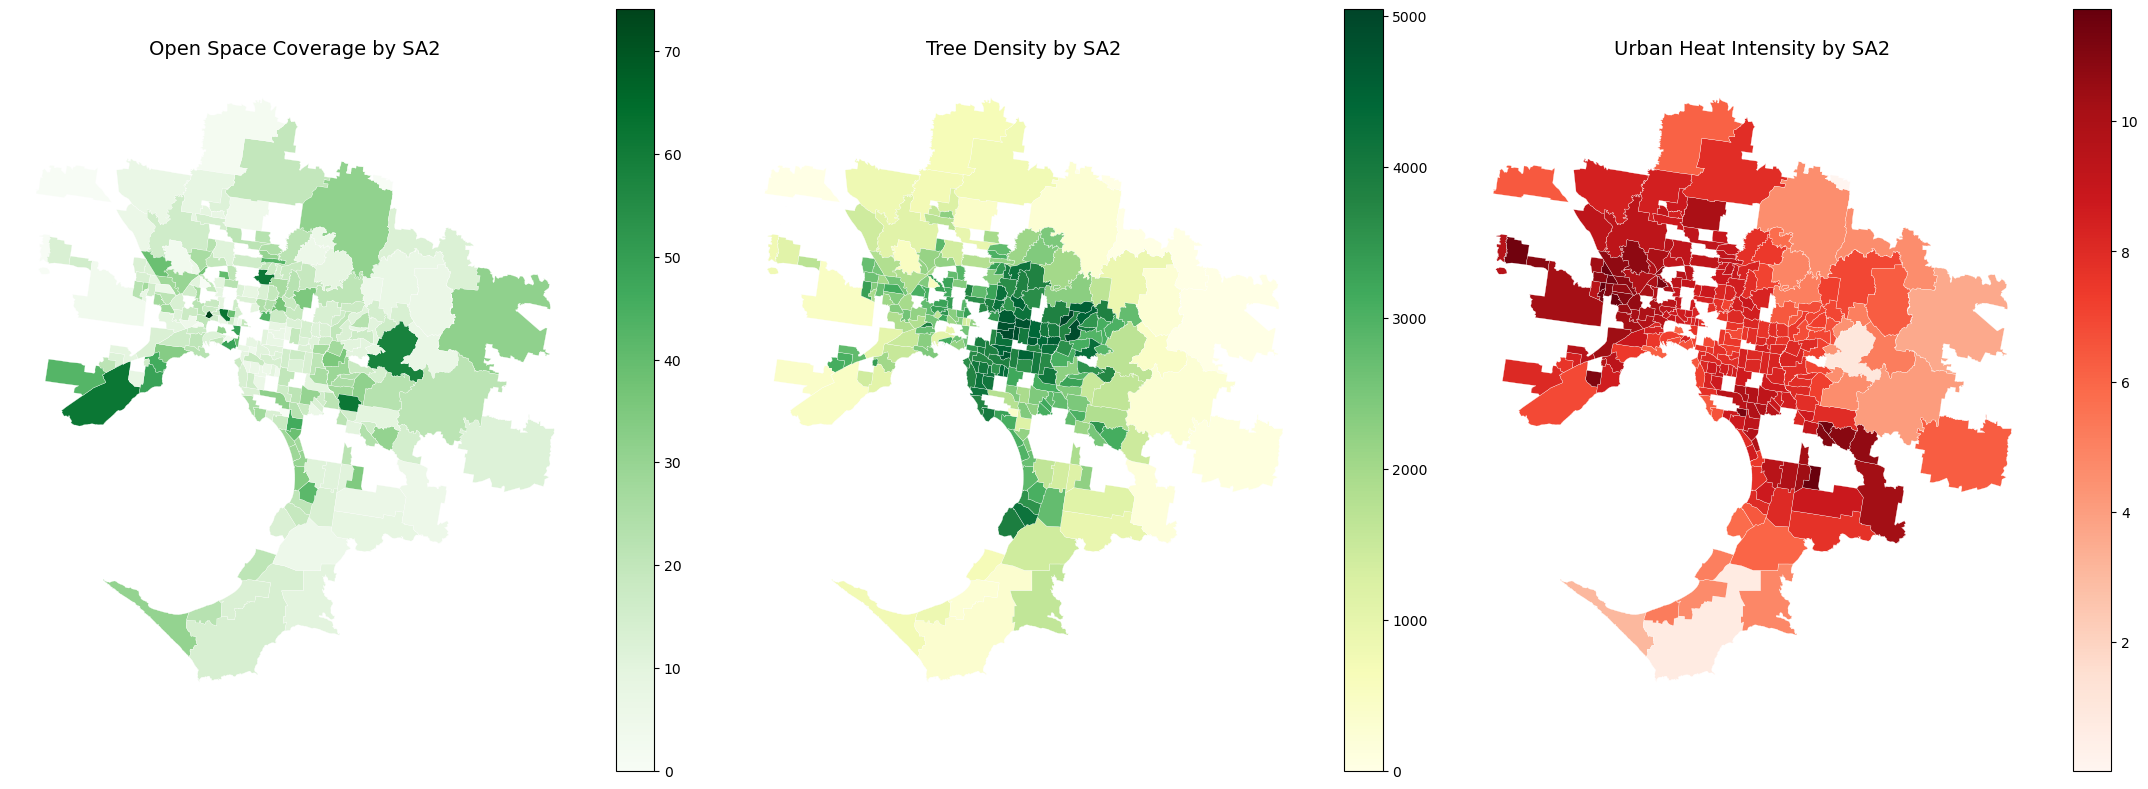

In [25]:
# Compare open space coverage, tree density and urban heat spatially

fig, (ax1, ax2, ax3) = plt.subplots(
    1,
    3,
    figsize=(22, 8)
)

q2.plot(
    column="open_space_coverage_pct",
    cmap="Greens",
    legend=True,
    ax=ax1,
    edgecolor="white",
    linewidth=0.2
)
ax1.set_title("Open Space Coverage by SA2", fontsize=14, pad=10)
ax1.set_axis_off()

q2.plot(
    column="tree_density",
    cmap="YlGn",
    legend=True,
    ax=ax2,
    edgecolor="white",
    linewidth=0.2
)
ax2.set_title("Tree Density by SA2", fontsize=14, pad=10)
ax2.set_axis_off()

q2.plot(
    column="UHI18_M",
    cmap="Reds",
    legend=True,
    ax=ax3,
    edgecolor="white",
    linewidth=0.2
)
ax3.set_title("Urban Heat Intensity by SA2", fontsize=14, pad=10)
ax3.set_axis_off()

fig.tight_layout()
plt.show()


The three maps compare the spatial patterns of open space coverage, tree density and urban heat intensity across SA2 areas. The open space coverage map and tree density map show that green resources are not evenly distributed across Greater Melbourne. Some outer and fringe areas have relatively high open space coverage, while many inner, western and northern areas show lower green coverage or lower tree density.

The urban heat intensity map shows that higher heat values are concentrated in several western, northern and south-eastern SA2 areas. When compared with the green space and tree density maps, some high-heat areas also appear to have relatively limited tree density or open space coverage. This suggests that green infrastructure may be related to local cooling conditions, although the spatial pattern is not entirely explained by green space alone.

Overall, the comparison indicates that urban heat exposure is likely influenced by a combination of factors, including open space coverage, tree density, land use, built-up density and surface materials. Therefore, future urban heat mitigation should consider both the amount of green space and the spatial distribution of trees and vegetation.

### 7.2 Green Space, Tree Density and Urban Heat Correlation Analysis

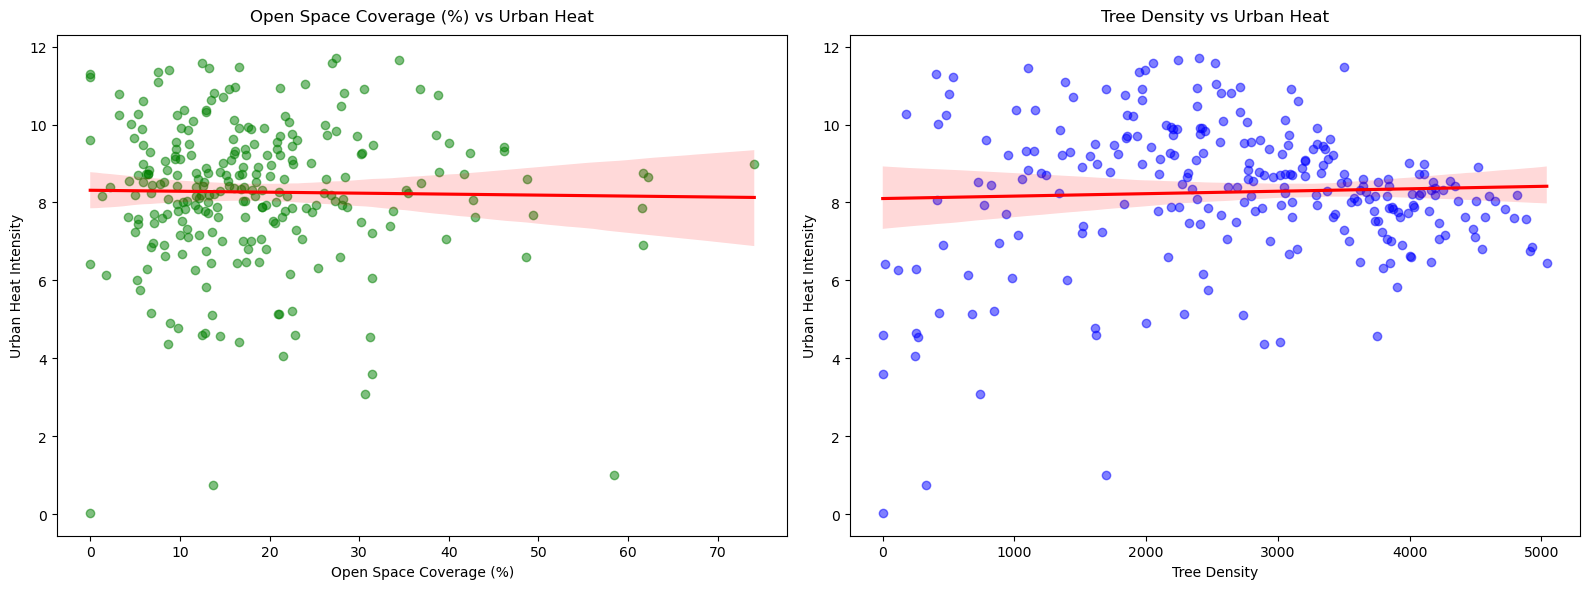

In [26]:
# Examine global relationships between greening indicators and urban heat

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

sns.regplot(
    x="open_space_coverage_pct",
    y="UHI18_M",
    data=q2,
    ax=ax1,
    scatter_kws={"alpha": 0.5, "color": "green"},
    line_kws={"color": "red"}
)

ax1.set_title(
    "Open Space Coverage (%) vs Urban Heat",
    fontsize=12,
    pad=10
)
ax1.set_xlabel("Open Space Coverage (%)")
ax1.set_ylabel("Urban Heat Intensity")

sns.regplot(
    x="tree_density",
    y="UHI18_M",
    data=q2,
    ax=ax2,
    scatter_kws={"alpha": 0.5, "color": "blue"},
    line_kws={"color": "red"}
)

ax2.set_title(
    "Tree Density vs Urban Heat",
    fontsize=12,
    pad=10
)
ax2.set_xlabel("Tree Density")
ax2.set_ylabel("Urban Heat Intensity")

fig.tight_layout()
plt.show()


The regression plots show that the linear relationships between green space indicators and urban heat intensity are relatively weak at the SA2 level. The trend line between open space coverage and UHI18_M is nearly horizontal, suggesting that open space coverage alone does not strongly explain variations in urban heat intensity across all SA2 areas.

The relationship between tree density and UHI18_M also appears weak and non-linear. Some areas with higher tree density have lower heat intensity, but the overall pattern is scattered. This indicates that tree density may contribute to local cooling, but it is not the only factor influencing urban heat.

These results suggest that urban heat in Greater Melbourne is shaped by multiple factors, including green space coverage, tree density, land use, built-up density, impervious surfaces and local urban form. Therefore, the cooling effect of green infrastructure should be interpreted together with broader spatial and environmental conditions.

### 7.3 Spatial Autocorrelation Analysis: Moran's I

#### 7.3.1 Global Moran's I

In [27]:
# Calculate Global Moran's I for urban heat intensity

from esda.moran import Moran
from libpysal.weights import Queen

moran_data = (
    q2[
        [
            "open_space_coverage_pct",
            "tree_density",
            "UHI18_M",
            "geometry"
        ]
    ]
    .dropna()
    .copy()
)

spatial_weights = Queen.from_dataframe(
    moran_data,
    use_index=False
)
spatial_weights.transform = "r"

moran_uhi = Moran(
    moran_data["UHI18_M"],
    spatial_weights
)

print(f"Moran's I: {moran_uhi.I:.4f}")
print(f"P-value:   {moran_uhi.p_sim:.4f}")


Moran's I: 0.7530
P-value:   0.0010


Global Moran's I was used to examine whether urban heat intensity shows spatial clustering across the SA2 areas. The result shows a Moran's I value of approximately 0.7530 with a p-value of 0.0010. This indicates a strong and statistically significant positive spatial autocorrelation in UHI18_M.

In other words, SA2 areas with high urban heat intensity tend to be located near other high-heat areas, while lower-heat areas also tend to cluster spatially. This result suggests that urban heat is not randomly distributed across Greater Melbourne, but forms clear regional spatial patterns.

#### 7.3.2 Bivariate Moran's I
Bivariate Moran's I is used to measure the spatial correlation between two different variables, assessing whether a local observation of one variable is significantly influenced by another variable in its surrounding neighborhood.

* Green Space Coverage

In [28]:
# Calculate bivariate Moran's I for coverage and neighbouring urban heat

from esda.moran import Moran_BV

mbv_coverage = Moran_BV(
    moran_data["open_space_coverage_pct"],
    moran_data["UHI18_M"],
    spatial_weights
)

print(f"Moran's I: {mbv_coverage.I:.4f}")
print(f"P-value:   {mbv_coverage.p_sim:.4f}")


Moran's I: 0.0534
P-value:   0.0570


The bivariate Moran's I between open space coverage and surrounding urban heat intensity is relatively weak, with a Moran's I value of approximately 0.0534. The p-value is around 0.0580, which is slightly above the 0.05 significance threshold. Therefore, this result does not provide strong statistical evidence of a significant spatial association at the 5% level.

This suggests that the spatial relationship between open space coverage and nearby urban heat is weak at the SA2 scale. Open space may still provide local cooling benefits, but its effect may be influenced by broader factors such as land use, built-up density, impervious surfaces and regional heat patterns.

* Tree Density

In [29]:
# Calculate bivariate Moran's I for tree density and neighbouring urban heat

mbv_density = Moran_BV(
    moran_data["tree_density"],
    moran_data["UHI18_M"],
    spatial_weights
)

print(f"Moran's I: {mbv_density.I:.4f}")
print(f"P-value:   {mbv_density.p_sim:.4f}")


Moran's I: 0.0415
P-value:   0.2160


The bivariate Moran's I between tree density and surrounding urban heat intensity is also weak, with a Moran's I value of approximately 0.0415 and a p-value of around 0.2350. This indicates that the spatial cross-correlation between tree density and urban heat is not statistically significant.

This does not mean that trees have no cooling effect. Instead, it suggests that at the SA2 scale, tree density alone does not strongly explain the spatial distribution of urban heat. The cooling effect of trees may be more localised and may depend on tree canopy structure, land surface materials, building density and the spatial arrangement of vegetation.

### 7.4 Land Cover Fraction Analysis:SA2-Level Land Cover Fractions from Raster Data

This section uses the 25m resolution Victorian Land Cover Time Series raster to derive SA2-level fractions of key land cover types via zonal statistics.

The following composite variables are created:
- tree_total_frac: sum of scattered trees (code 5), treed native (12), and urban vegetation (6)
- grass_total_frac: sum of native grassland (7) and exotic pasture/grass (8)
- built_frac: built environment (code 4)
- water_frac: water bodies (code 1)
- bare_frac: sum of native bare ground (2) and non‑native bare ground (3)

In [30]:
# Load land cover raster
raster_path = raw_dir / "landcover.tif"

# Match q2 CRS with raster CRS
with rasterio.open(raster_path) as src:
    raster_crs = src.crs

q2_projected = q2.to_crs(raster_crs)

# Perform zonal statistics
zonal_results = zonal_stats(
    q2_projected,
    raster_path,
    categorical=True
)

print("Number of SA2 polygons:", len(q2_projected))
print("Number of zonal results:", len(zonal_results))
print("First zonal result:", zonal_results[0])

Number of SA2 polygons: 257
Number of zonal results: 257
First zonal result: {1: 232, 2: 10252, 3: 137, 4: 55, 5: 28, 6: 1, 8: 308, 10: 85, 11: 39, 12: 32, 13: 12, 14: 17, 18: 2}


In [31]:
# Calculate selected land cover fractions for each SA2 area

land_cover_codes = {
    "water": 1,
    "built": 4,
    "scattered_trees": 5,
    "urban_vegetation": 6,
    "native_grass": 7,
    "exotic_grass": 8,
    "native_trees": 12
}

tree_total_fraction = []
grass_total_fraction = []
built_fraction = []
water_fraction = []

for zone in zonal_results:
    total_pixels = sum(zone.values())

    if total_pixels == 0:
        tree_total_fraction.append(0)
        grass_total_fraction.append(0)
        built_fraction.append(0)
        water_fraction.append(0)
        continue

    tree_pixels = (
        zone.get(land_cover_codes["scattered_trees"], 0)
        + zone.get(land_cover_codes["native_trees"], 0)
        + zone.get(land_cover_codes["urban_vegetation"], 0)
    )

    grass_pixels = (
        zone.get(land_cover_codes["native_grass"], 0)
        + zone.get(land_cover_codes["exotic_grass"], 0)
    )

    tree_total_fraction.append(tree_pixels / total_pixels)
    grass_total_fraction.append(grass_pixels / total_pixels)
    built_fraction.append(
        zone.get(land_cover_codes["built"], 0)
        / total_pixels
    )
    water_fraction.append(
        zone.get(land_cover_codes["water"], 0)
        / total_pixels
    )

q2_projected["tree_total_frac"] = tree_total_fraction
q2_projected["grass_total_frac"] = grass_total_fraction
q2_projected["built_frac"] = built_fraction
q2_projected["water_frac"] = water_fraction

q2_projected[
    [
        "sa2_name",
        "tree_total_frac",
        "grass_total_frac",
        "built_frac",
        "water_frac"
    ]
].head()


,sa2_name,tree_total_frac,grass_total_frac,built_frac,water_frac
0,Hoppers Crossing - South,0.005446,0.027500,0.004911,0.020714
1,Werribee - South,0.104347,0.425609,0.146950,0.003274
2,Werribee - East,0.025337,0.065521,0.014686,0.009441
3,Werribee - West,0.194814,0.043992,0.180966,0.000471
4,Point Nepean,0.285008,0.089364,0.128841,0.000968


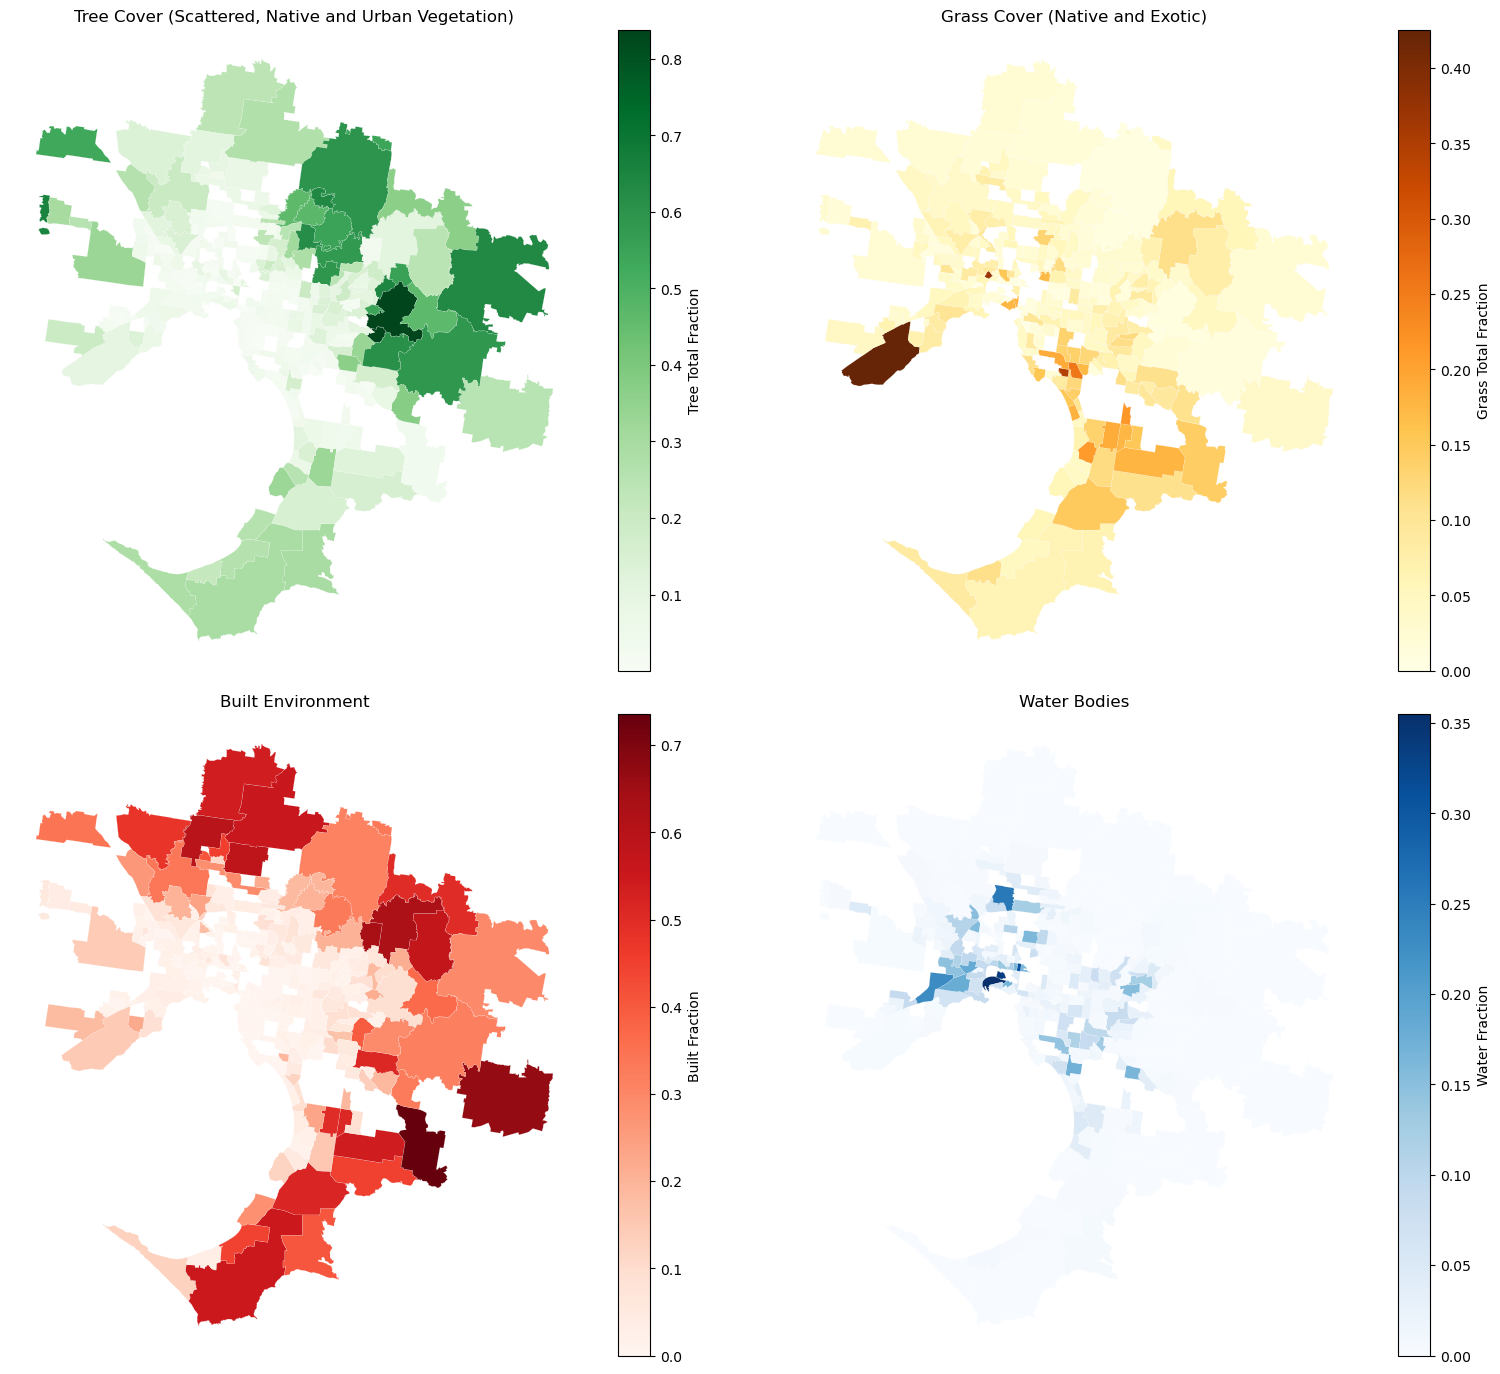

In [32]:
# Map selected land cover fractions

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 14)
)
axes = axes.flatten()

q2_projected.plot(
    column="tree_total_frac",
    cmap="Greens",
    legend=True,
    legend_kwds={"label": "Tree Total Fraction"},
    edgecolor="white",
    linewidth=0.1,
    ax=axes[0]
)
axes[0].set_title(
    "Tree Cover (Scattered, Native and Urban Vegetation)",
    fontsize=12
)
axes[0].axis("off")

q2_projected.plot(
    column="grass_total_frac",
    cmap="YlOrBr",
    legend=True,
    legend_kwds={"label": "Grass Total Fraction"},
    edgecolor="white",
    linewidth=0.1,
    ax=axes[1]
)
axes[1].set_title(
    "Grass Cover (Native and Exotic)",
    fontsize=12
)
axes[1].axis("off")

q2_projected.plot(
    column="built_frac",
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "Built Fraction"},
    edgecolor="white",
    linewidth=0.1,
    ax=axes[2]
)
axes[2].set_title("Built Environment", fontsize=12)
axes[2].axis("off")

q2_projected.plot(
    column="water_frac",
    cmap="Blues",
    legend=True,
    legend_kwds={"label": "Water Fraction"},
    edgecolor="white",
    linewidth=0.1,
    ax=axes[3]
)
axes[3].set_title("Water Bodies", fontsize=12)
axes[3].axis("off")

fig.tight_layout()
plt.show()


These four spatial pattern maps reveal the geological environment of the Greater Melbourne area: High built environment values ​​are extremely concentrated in the city center, north and southeast of Melbourne, while tree cover is lower in these areas, which also have a stronger heat island effect.

### 7.5 Geographically Weighted Regression (GWR) Model

In [33]:
# Fit a geographically weighted regression model

from mgwr.gwr import GWR
from mgwr.sel_bw import Sel_BW

q2_gwr = q2.to_crs(TARGET_CRS).copy()

gwr_data = (
    q2_gwr[
        [
            "open_space_coverage_pct",
            "tree_density",
            "UHI18_M",
            "geometry"
        ]
    ]
    .dropna()
    .copy()
)

if len(gwr_data) < 30:
    raise ValueError(
        "Insufficient complete observations for GWR analysis."
    )

print(
    "Number of observations used in GWR:",
    len(gwr_data)
)

centroids = gwr_data.geometry.centroid
coords = np.column_stack(
    (centroids.x, centroids.y)
)

y = gwr_data[
    "UHI18_M"
].to_numpy().reshape((-1, 1))

X_variables = gwr_data[
    [
        "open_space_coverage_pct",
        "tree_density"
    ]
].to_numpy()

bandwidth_selector = Sel_BW(
    coords,
    y,
    X_variables,
    kernel="gaussian",
    fixed=False
)

best_bw = bandwidth_selector.search(
    criterion="AICc"
)

print("Best bandwidth:", best_bw)

gwr_model = GWR(
    coords,
    y,
    X_variables,
    bw=best_bw,
    kernel="gaussian",
    fixed=False
)

gwr_results = gwr_model.fit()
gwr_results.summary()


Number of observations used in GWR: 257
Best bandwidth: 47.0
Model type                                                         Gaussian
Number of observations:                                                 257
Number of covariates:                                                     3

Global Regression Results
---------------------------------------------------------------------------
Residual sum of squares:                                            854.019
Log-likelihood:                                                    -518.980
AIC:                                                               1043.960
AICc:                                                              1046.119
BIC:                                                               -555.446
R2:                                                                   0.002
Adj. R2:                                                             -0.006

Variable                              Est.         SE  t(Est/SE)    p-value

In [34]:
# Attach local GWR results to the spatial dataset

gwr_output = gwr_data.copy()

gwr_output["gwr_intercept"] = (
    gwr_results.params[:, 0]
)
gwr_output["gwr_coverage_coef"] = (
    gwr_results.params[:, 1]
)
gwr_output["gwr_tree_density_coef"] = (
    gwr_results.params[:, 2]
)
gwr_output["gwr_local_r2"] = (
    gwr_results.localR2
)

gwr_output[
    [
        "open_space_coverage_pct",
        "tree_density",
        "UHI18_M",
        "gwr_coverage_coef",
        "gwr_tree_density_coef",
        "gwr_local_r2"
    ]
].head()


,open_space_coverage_pct,tree_density,UHI18_M,gwr_coverage_coef,gwr_tree_density_coef,gwr_local_r2
0,11.790865,3050.020758,8.385504,-0.022109,-0.000430,0.389830
1,61.657575,456.849792,6.900058,-0.017769,-0.000317,0.377953
2,21.359952,3108.183493,7.630220,-0.020720,-0.000401,0.390374
3,42.719471,411.225408,8.069294,-0.016938,-0.000311,0.382648
4,30.647845,734.992220,3.073223,-0.004554,0.000069,0.286816


#### 7.5.1 OLS Results

The ordinary least squares (OLS) linear regression model to empirically test the linear hypothesis of $$UHI = \beta_0 + \beta_1 \cdot \text{Open Space Coverage} + \beta_2 \cdot \text{Tree Density}$$ across SA2 spatial units in the Greater Melbourne area.

Based on the output, we can see that the $p$-values ​​for both independent variables are > 0.05 (open space coverage: $p$=0.824, tree density: $p$=0.512), therefore we fail to refuse the null hypothesis, indicating no significant linear relationship.

$R^2 ≈ $ 0.002, and after adjustment, $R^2$ < 0, suggesting that open space coverage and tree density have almost no global linear explanatory power for urban heat island intensity (UHI).

The OLS model concludes that increasing open space or tree density does not linearly reduce heat island intensity across the entire Melbourne region.

#### 7.5.2 GWR Model

The GWR model is specified as:

$$
\text{UHI}_i = \beta_0(u_i, v_i) + \beta_1(u_i, v_i) \cdot \text{Open Space Coverage}_i + \beta_2(u_i, v_i) \cdot \text{Tree Density}_i + \varepsilon_i
$$

where:

- $(u_i, v_i)$ are the spatial coordinates (e.g., projected easting and northing) of SA2 centroid $i$;
- $\beta_0(u_i, v_i)$ is the local intercept at location $i$;
- $\beta_1(u_i, v_i)$ and $\beta_2(u_i, v_i)$ are local coefficients for open space coverage and tree density, respectively;
- $\varepsilon_i$ is the random error term.

The local coefficients are estimated via weighted least squares using an adaptive Gaussian kernel, with bandwidth selected by minimizing the AICc criterion.

The GWR's $R^2$ = 0.325, adjusted $R^2$ = 0.299, is a significant improvement compared to the global model's 0.002. This indicates that incorporating spatial location into the model significantly enhances its explanatory power.

The AICc decreased from 1046 to 959.6, demonstrating that the GWR model's fit is far superior to ordinary linear regression.

The bandwidth of 47 neighbors indicates that each local regression uses approximately 47 neighboring SA2 regions for weighted fitting, suggesting a moderate scale of influence.

From the parameter statistics table, we can see:

* Intercept (X0): Mean is 9.32, range from 6.78 to 10.75, indicating significant differences in the basic heat island intensity across different regions.

* Open space coverage coefficient (X1): Mean is -0.008, range from -0.024 to 0.012, indicating that in most areas, cover has a slight negative impact on UHI, i.e., cooling, but in some areas it has a positive impact, i.e., anomalous warming. Significant spatial heterogeneity is observed.

* Tree density coefficient (X2): Mean close to 0, range from -0.001 to 0.000, indicating that the effect of tree density is very weak and inconsistent in direction.

#### 7.5.3 GWR Local $R^2$ Spatial Distribution

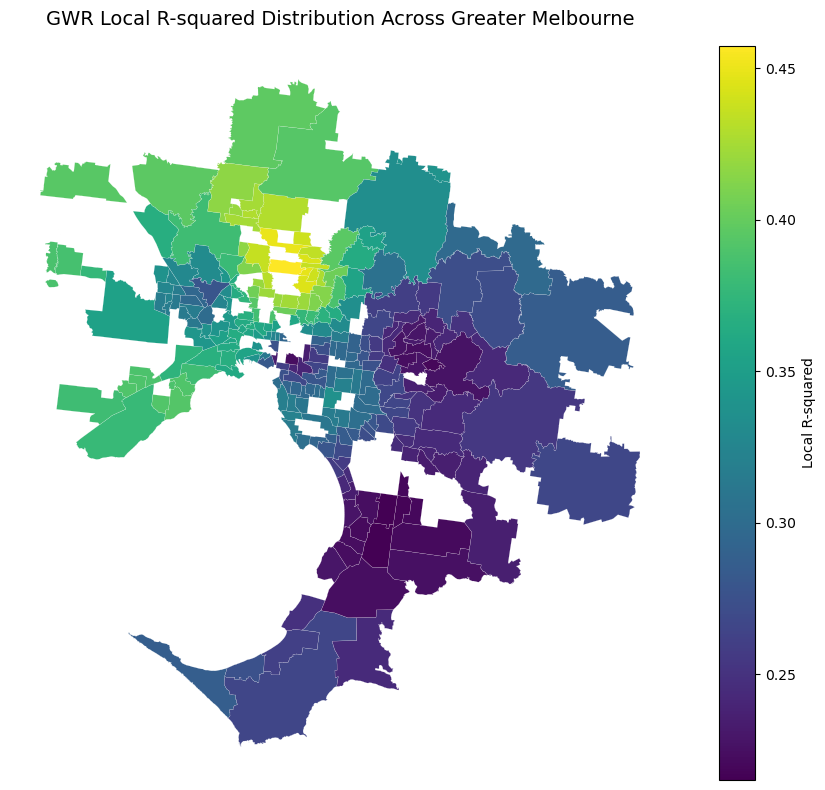

In [35]:
# Map the spatial distribution of local GWR R-squared values

fig, ax = plt.subplots(figsize=(10, 8))

gwr_output.plot(
    column="gwr_local_r2",
    cmap="viridis",
    legend=True,
    linewidth=0.1,
    edgecolor="white",
    legend_kwds={
        "label": "Local R-squared"
    },
    ax=ax
)

ax.set_title(
    "GWR Local R-squared Distribution Across Greater Melbourne",
    fontsize=14,
    pad=15
)
ax.axis("off")

fig.tight_layout()
plt.show()


This local $R^2$ spatial distribution map confirms the strong spatial nonstationarity of the greening index's effect on mitigating the urban heat island effect (UHI). The model's explanatory power increases from a very low value in the southeast coastal area ($R^2$ around 0.23) towards the northwest, peaking in Melbourne's northwest suburbs and northern edge ($R^2$ > 0.45). This clear gradient pattern indicates that in the northwest region, far from the influence of oceanic air currents, tree density and green cover affect surface temperature, and the model can explain nearly half of the local heat island intensity variation. Conversely, in the southern and eastern coastal areas, the independent explanatory power of the greening index is reduced due to complex coastal climates (such as sea breeze modulation).

#### 7.5.4 Visualising Spatial Heterogeneity through GWR

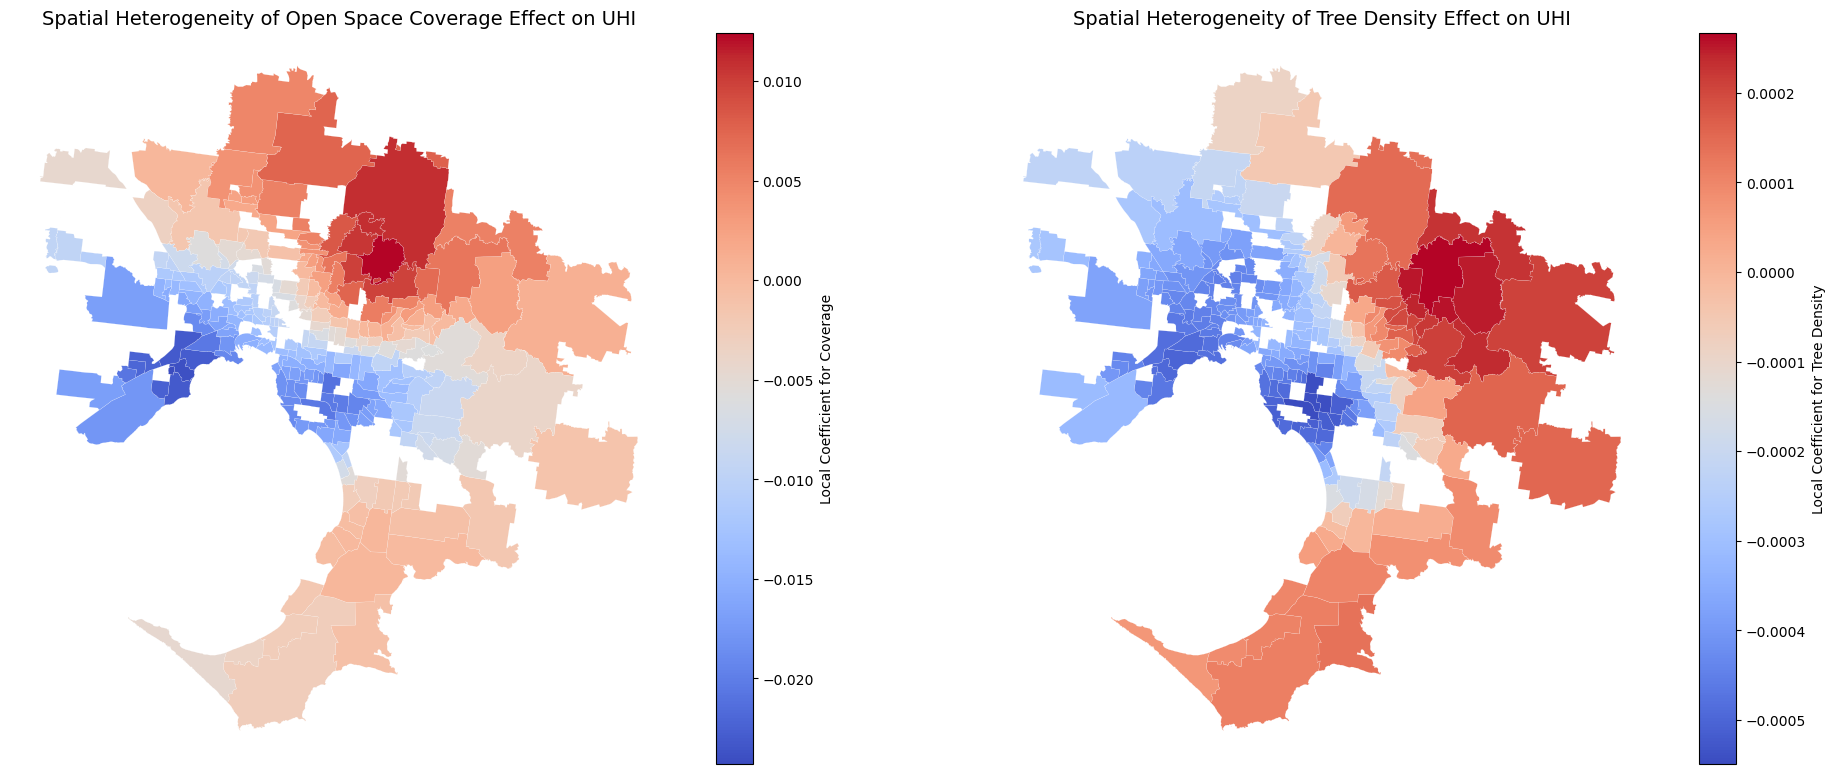

In [36]:
# Map the spatial variation in local GWR coefficients

fig, axes = plt.subplots(
    1,
    2,
    figsize=(20, 8)
)

gwr_output.plot(
    column="gwr_coverage_coef",
    cmap="coolwarm",
    legend=True,
    linewidth=0.1,
    edgecolor="white",
    ax=axes[0],
    legend_kwds={
        "label": "Local Coefficient for Coverage"
    }
)

axes[0].set_title(
    "Spatial Heterogeneity of Open Space Coverage Effect on UHI",
    fontsize=14
)
axes[0].axis("off")

gwr_output.plot(
    column="gwr_tree_density_coef",
    cmap="coolwarm",
    legend=True,
    linewidth=0.1,
    edgecolor="white",
    ax=axes[1],
    legend_kwds={
        "label": "Local Coefficient for Tree Density"
    }
)

axes[1].set_title(
    "Spatial Heterogeneity of Tree Density Effect on UHI",
    fontsize=14
)
axes[1].axis("off")

fig.tight_layout()
plt.show()


* Spatial Heterogeneity of Open Space Coverage Effect on UHI

The impact of open space coverage on UHI exhibits a south-north spatial divide.

Positive values ​​in these localised areas mean that the higher the open space coverage, the higher the urban heat island intensity (UHI). This contradicts the conventional understanding that open spaces typically have a cooling effect. Possible reasons include the possibility that these open spaces might be bare soil, dry grass, or sports fields.

Negative values ​​indicate a consistent cooling effect: increased cover reduces the UHI, as seen in Melbourne's CBD and southwest coastal areas, suggesting that the construction of open green spaces in these regions yields significant cooling returns.

The coexistence of positive and negative coefficients indicates that the effect of open spaces is not unidirectional, but heavily dependent on local vegetation type, soil moisture, surrounding building density, and wind conditions.

* Spatial Heterogeneity of Tree Density Effect on UHI

The impact of tree density on UHI exhibits a clear east-west spatial divide.

Most areas show negative values, indicating that higher tree density corresponds to lower UHI—a consistent cooling effect. The dark blue areas are highly concentrated in Melbourne's west and the inner west. In the older eastern suburbs, possibly because the existing urban forests are already close to saturation, further increases in tree density have reduced their moderating effect on overall temperature.

Compared to open spaces, the coefficient for tree density is more stable in sign, almost entirely negative, indicating that the shading effect of trees dominates in most areas of Melbourne, and the cooling mechanism is stable.

### 7.6 Conclusion and Limitation

This section investigates the impact of open space coverage and tree density on the intensity of the urban heat island in the Melbourne metropolitan area. Traditional statistical methods did not reveal a significant global linear relationship, and spatial cluster analysis also indicated that the heat island effect is mainly driven by regional-scale processes. However, geographically weighted regression (GWR) further reveals that tree density exhibits a stable cooling effect across almost the entire study area (with consistently negative local coefficients), while the impact of open space coverage shows strong spatial heterogeneity: it can cool in some areas but may exacerbate the heat island effect in others.This suggests that the cooling effect of green infrastructure cannot be generalized. Tree density is a more reliable factor in mitigating the heat island, while the effect of open space depends on its specific type, humidity conditions, and surrounding environment. Therefore, heat island mitigation strategies in Melbourne should prioritize increasing tree density and involve specific analysis and design of open spaces.

**Limitations:**

1. The analysis was conducted at the SA2 level, which may have masked significant differences within suburban areas. When data is aggregated to relatively large spatial units, the localized cooling effects of parks and street trees may not be fully captured.

2. Open space coverage and tree density were used as a simplified indicator of the quality of green infrastructure. This dataset does not distinguish between different vegetation types, canopy density, tree height, irrigation conditions, or accessibility, all of which can influence cooling effects.

3. Residual analysis strongly suggests that future research should incorporate more environmental and urban variables, such as building density, industrial land, elevation, and distance from the coast.

## 8. Social Vulnerability Analysis

This section uses ABS Census data to measure social vulnerability at the SA2 level. The indicators include median household income, elderly population percentage, children population percentage and population density. This part is later used as one input for the final priority intervention index.

### 8.1 Prepare data

In [37]:
# Load the remaining Census table

# G01 was loaded in Section 6 and is reused here.
g02 = pd.read_csv(
    census_dir / "2021Census_G02_VIC_SA2.csv",
    low_memory=False
)

print("G01 shape:", g01.shape)
print("G02 shape:", g02.shape)

g01.head()


G01 shape: (524, 109)
G02 shape: (524, 9)


,SA2_CODE_2021,Tot_P_M,Tot_P_F,Tot_P_P,Age_0_4_yr_M,Age_0_4_yr_F,Age_0_4_yr_P,Age_5_14_yr_M,Age_5_14_yr_F,Age_5_14_yr_P,...,High_yr_schl_comp_Yr_8_belw_P,High_yr_schl_comp_D_n_g_sch_M,High_yr_schl_comp_D_n_g_sch_F,High_yr_schl_comp_D_n_g_sch_P,Count_psns_occ_priv_dwgs_M,Count_psns_occ_priv_dwgs_F,Count_psns_occ_priv_dwgs_P,Count_Persons_other_dwgs_M,Count_Persons_other_dwgs_F,Count_Persons_other_dwgs_P
0,201011001,8188,8648,16835,623,585,1213,1453,1364,2815,...,430,23,22,45,7786,8263,16055,268,313,585
1,201011002,5711,6420,12131,267,224,490,658,630,1290,...,355,10,13,22,5152,5811,10969,755,766,1521
2,201011005,3594,3664,7261,190,172,357,561,587,1148,...,169,10,8,14,3308,3417,6722,217,215,435
3,201011006,5111,5553,10661,382,426,804,784,683,1464,...,408,22,13,39,4837,5211,10052,227,270,501
4,201011007,2172,2055,4230,125,99,223,338,326,668,...,126,4,3,8,2099,2013,4107,37,37,71


In [38]:
# Prepare age and population indicators

g01_clean = g01.copy()

g01_clean["sa2_code"] = (
    g01_clean["SA2_CODE_2021"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

age_columns = [
    "Age_0_4_yr_P",
    "Age_5_14_yr_P",
    "Age_65_74_yr_P",
    "Age_75_84_yr_P",
    "Age_85ov_P",
    "Tot_P_P"
]

g01_clean[age_columns] = g01_clean[
    age_columns
].apply(
    pd.to_numeric,
    errors="coerce"
)

g01_clean["children_pop"] = (
    g01_clean["Age_0_4_yr_P"]
    + g01_clean["Age_5_14_yr_P"]
)

g01_clean["elderly_pop"] = (
    g01_clean["Age_65_74_yr_P"]
    + g01_clean["Age_75_84_yr_P"]
    + g01_clean["Age_85ov_P"]
)

g01_clean["total_population"] = (
    g01_clean["Tot_P_P"]
)

g01_clean["children_pct"] = (
    g01_clean["children_pop"]
    / g01_clean["total_population"]
    * 100
).where(
    g01_clean["total_population"] > 0
)

g01_clean["elderly_pct"] = (
    g01_clean["elderly_pop"]
    / g01_clean["total_population"]
    * 100
).where(
    g01_clean["total_population"] > 0
)

g01_clean = (
    g01_clean[
        [
            "sa2_code",
            "children_pop",
            "elderly_pop",
            "total_population",
            "children_pct",
            "elderly_pct"
        ]
    ]
    .drop_duplicates(subset="sa2_code")
    .copy()
)

g01_clean.head()


,sa2_code,children_pop,elderly_pop,total_population,children_pct,elderly_pct
0,201011001,4028,2178,16835,23.926344,12.937333
1,201011002,1780,2826,12131,14.673151,23.295689
2,201011005,1505,1334,7261,20.727173,18.372125
3,201011006,2268,1578,10661,21.273802,14.801613
4,201011007,891,608,4230,21.063830,14.373522


In [39]:
# Prepare the median weekly household income indicator

g02_clean = g02.copy()

g02_clean["sa2_code"] = (
    g02_clean["SA2_CODE_2021"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

g02_clean["median_income"] = pd.to_numeric(
    g02_clean["Median_tot_hhd_inc_weekly"],
    errors="coerce"
)

g02_clean = (
    g02_clean[
        [
            "sa2_code",
            "median_income"
        ]
    ]
    .drop_duplicates(subset="sa2_code")
    .copy()
)

g02_clean.head()


,sa2_code,median_income
0,201011001,1952
1,201011002,1573
2,201011005,1927
3,201011006,1627
4,201011007,2065


In [40]:
# Merge the Census indicator tables

census_clean = g01_clean.merge(
    g02_clean,
    on="sa2_code",
    how="left",
    validate="one_to_one"
)

census_clean = census_clean.dropna(
    subset=[
        "children_pct",
        "elderly_pct",
        "total_population",
        "median_income"
    ]
).copy()

print(
    "Clean Census indicator table:",
    census_clean.shape
)

census_clean.head()


Clean Census indicator table: (520, 7)


,sa2_code,children_pop,elderly_pop,total_population,children_pct,elderly_pct,median_income
0,201011001,4028,2178,16835,23.926344,12.937333,1952
1,201011002,1780,2826,12131,14.673151,23.295689,1573
2,201011005,1505,1334,7261,20.727173,18.372125,1927
3,201011006,2268,1578,10661,21.273802,14.801613,1627
4,201011007,891,608,4230,21.063830,14.373522,2065


In [41]:
# Prepare the SA2 boundary for social vulnerability analysis

sa2_melb = sa2_master.copy()

sa2_melb["sa2_code"] = (
    sa2_melb["sa2_code"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

print("SA2 boundary prepared successfully.")
print("Number of SA2 areas:", len(sa2_melb))

sa2_melb.head()


SA2 boundary prepared successfully.
Number of SA2 areas: 360


,sa2_code,sa2_name,area_m2,area_km2,geometry
0,213051362,Hoppers Crossing - South,7.012411e+06,7.012411,"MULTIPOLYGON (((294653.085 5806028.552, 294645..."
1,213051368,Werribee - South,1.140616e+08,114.061560,"MULTIPOLYGON (((300955.332 5798020.917, 300955..."
2,213051467,Werribee - East,7.758551e+06,7.758551,"MULTIPOLYGON (((292554.398 5804662.406, 292548..."
3,213051468,Werribee - West,5.991604e+07,59.916045,"MULTIPOLYGON (((288867.598 5797885.557, 288870..."
4,213051579,Manor Lakes - Quandong,1.493557e+07,14.935574,"MULTIPOLYGON (((281564.588 5805244.323, 284521..."


In [42]:
# Join Census indicators to the SA2 boundary

sa2_census = sa2_melb.merge(
    census_clean,
    on="sa2_code",
    how="left",
    validate="one_to_one"
)

sa2_census["population_density"] = (
    sa2_census["total_population"]
    / sa2_census["area_km2"]
).where(
    sa2_census["area_km2"] > 0
)

sa2_census[
    [
        "sa2_code",
        "sa2_name",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"
    ]
].head()


,sa2_code,sa2_name,median_income,children_pct,elderly_pct,population_density
0,213051362,Hoppers Crossing - South,1470.0,19.470488,15.619007,2676.967910
1,213051368,Werribee - South,1802.0,18.887567,15.425342,147.376557
2,213051467,Werribee - East,1374.0,19.495003,15.228827,2450.199801
3,213051468,Werribee - West,1995.0,23.123405,8.030079,372.871741
4,213051579,Manor Lakes - Quandong,2309.0,30.519970,3.570083,710.786197


In [43]:
# Check missing values after joining

sa2_census[
    [
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"
    ]
].isna().sum()

median_income         2
children_pct          2
elderly_pct           2
population_density    2
dtype: int64

In [44]:
# Check which SA2s have missing census data

missing_census = sa2_census[
    sa2_census["median_income"].isna()
][
    [
        "sa2_code",
        "sa2_name",
        "area_km2"
    ]
]

missing_census

,sa2_code,sa2_name,area_km2
88,206041127,West Melbourne - Industrial,6.199354
187,206041507,Royal Botanic Gardens Victoria,1.351088


In [45]:
# Remove SA2s with missing census indicators

sa2_census = sa2_census.dropna(
    subset=[
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"
    ]
).copy()

# Check number of SA2s after removing missing rows
print("Number of SA2s after removing missing census rows:", len(sa2_census))

# Check missing values again
sa2_census[
    [
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"
    ]
].isna().sum()

Number of SA2s after removing missing census rows: 358


median_income         0
children_pct          0
elderly_pct           0
population_density    0
dtype: int64

### 8.2 Calculate social vulnerability score

In [46]:
# Define scaling functions and calculate social vulnerability

def min_max_scale(series):
    """Scale valid values to the interval from zero to one."""
    values = pd.to_numeric(
        series,
        errors="coerce"
    )
    value_range = values.max() - values.min()

    if value_range == 0:
        return pd.Series(
            0.0,
            index=values.index
        )

    return (
        values - values.min()
    ) / value_range


def reverse_min_max_scale(series):
    """Assign higher scores to lower original values."""
    values = pd.to_numeric(
        series,
        errors="coerce"
    )
    value_range = values.max() - values.min()

    if value_range == 0:
        return pd.Series(
            0.0,
            index=values.index
        )

    return (
        values.max() - values
    ) / value_range


sa2_census["income_score"] = reverse_min_max_scale(
    sa2_census["median_income"]
)
sa2_census["elderly_score"] = min_max_scale(
    sa2_census["elderly_pct"]
)
sa2_census["children_score"] = min_max_scale(
    sa2_census["children_pct"]
)
sa2_census["density_score"] = min_max_scale(
    sa2_census["population_density"]
)

sa2_census["social_vulnerability_score"] = (
    sa2_census[
        [
            "income_score",
            "elderly_score",
            "children_score",
            "density_score"
        ]
    ]
    .mean(axis=1)
)

top_social_table = (
    sa2_census
    .sort_values(
        "social_vulnerability_score",
        ascending=False
    )
    .head(10)
    [
        [
            "sa2_name",
            "median_income",
            "elderly_pct",
            "children_pct",
            "population_density",
            "social_vulnerability_score"
        ]
    ]
    .copy()
)

top_social_table


,sa2_name,median_income,elderly_pct,children_pct,population_density,social_vulnerability_score
36,Riddells Creek,2156.0,16.805026,19.250617,9.554337e+08,0.573641
34,Romsey,2004.0,16.720855,19.609847,5.722693e+08,0.488679
162,Rosebud - McCrae,1155.0,33.372559,14.029812,9.642079e+02,0.475846
185,Mornington - West,1389.0,38.701446,10.802382,1.652279e+03,0.465037
11,Point Nepean,1430.0,32.239665,13.871082,2.948333e+02,0.443697
20,Melton,1061.0,20.213036,18.792797,7.994316e+02,0.436030
163,Dromana,1398.0,30.734700,13.444561,2.966541e+02,0.433397
184,Mornington - East,1502.0,26.003295,17.930807,1.033186e+03,0.428880
59,Campbellfield - Coolaroo,1104.0,15.638039,21.679018,8.828945e+02,0.425286
19,Melton South - Weir Views,1363.0,10.991716,26.695882,1.511003e+03,0.412157


In [47]:
# Retain the social vulnerability variables used later

social_vulnerability_sa2 = sa2_census[
    [
        "sa2_code",
        "sa2_name",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density",
        "total_population",
        "income_score",
        "elderly_score",
        "children_score",
        "density_score",
        "social_vulnerability_score",
        "geometry"
    ]
].copy()

print("Social vulnerability variables are ready.")
print(
    "Number of SA2 areas:",
    len(social_vulnerability_sa2)
)


Social vulnerability variables are ready.
Number of SA2 areas: 358


### 8.3 Map social vulnerability

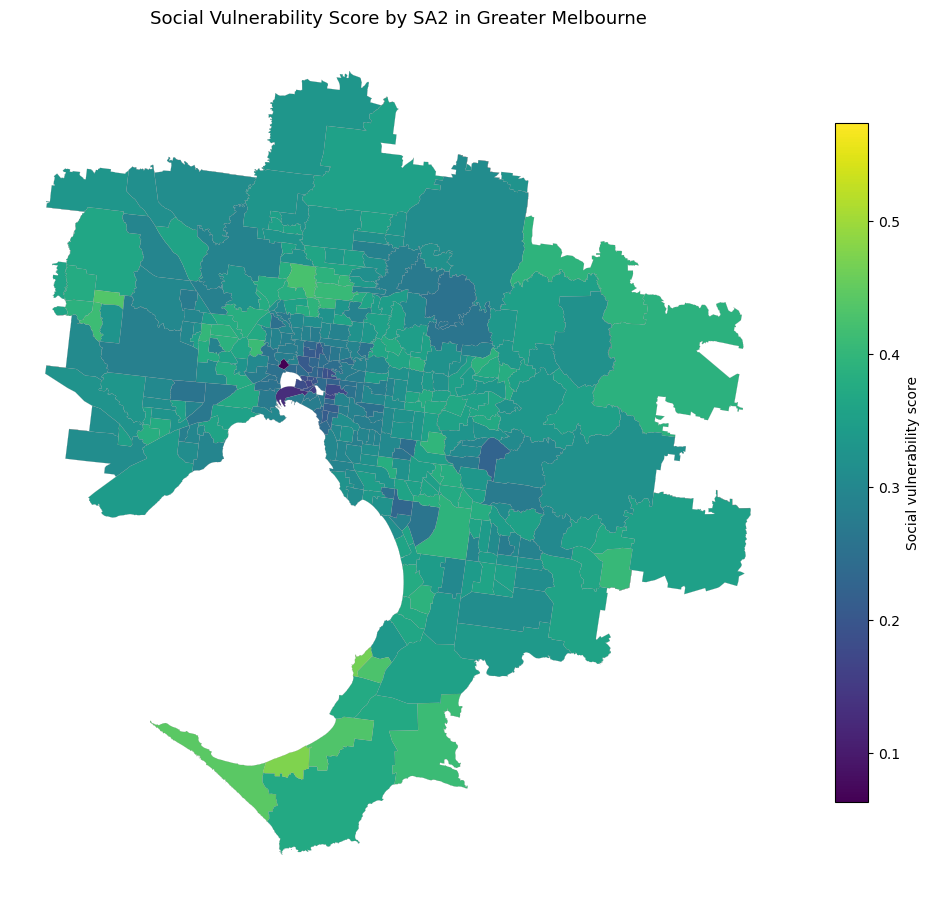

In [48]:
# Map the social vulnerability score

fig, ax = plt.subplots(figsize=(10, 10))

social_vulnerability_sa2.plot(
    column="social_vulnerability_score",
    legend=True,
    legend_kwds={
        "label": "Social vulnerability score",
        "shrink": 0.7
    },
    edgecolor="grey",
    linewidth=0.1,
    ax=ax
)

ax.set_title(
    "Social Vulnerability Score by SA2 in Greater Melbourne",
    fontsize=13
)
ax.axis("off")

fig.tight_layout()
plt.show()


### 8.4 Join social vulnerability with green space and urban heat

In [49]:
# Join social vulnerability with environmental indicators

q2_attributes = (
    q2[
        [
            "sa2_code",
            "open_space_coverage_pct",
            "open_space_area_m2",
            "UHI18_M",
            "tree_density"
        ]
    ]
    .drop_duplicates(subset="sa2_code")
    .copy()
)

priority_result = social_vulnerability_sa2.merge(
    q2_attributes,
    on="sa2_code",
    how="inner",
    validate="one_to_one"
)

priority_result[
    [
        "sa2_code",
        "sa2_name",
        "open_space_coverage_pct",
        "open_space_area_m2",
        "UHI18_M",
        "tree_density",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density",
        "total_population",
        "social_vulnerability_score"
    ]
].head()


,sa2_code,sa2_name,open_space_coverage_pct,open_space_area_m2,UHI18_M,tree_density,median_income,children_pct,elderly_pct,population_density,total_population,social_vulnerability_score
0,213051362,Hoppers Crossing - South,11.790865,8.268239e+05,8.385504,3050.020758,1470.0,19.470488,15.619007,2676.967910,18772.0,0.376548
1,213051368,Werribee - South,61.657575,7.032759e+07,6.900058,456.849792,1802.0,18.887567,15.425342,147.376557,16810.0,0.342269
2,213051467,Werribee - East,21.359952,1.657223e+06,7.630220,3108.183493,1374.0,19.495003,15.228827,2450.199801,19010.0,0.382455
3,213051468,Werribee - West,42.719471,2.559582e+07,8.069294,411.225408,1995.0,23.123405,8.030079,372.871741,22341.0,0.310958
4,214021383,Point Nepean,30.647845,2.059349e+07,3.073223,734.992220,1430.0,13.871082,32.239665,294.833273,19811.0,0.443697


In [50]:
# Check missing values after joining

priority_result[
    [
        "open_space_coverage_pct",
        "open_space_area_m2",
        "UHI18_M",
        "tree_density",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density",
        "total_population",
        "social_vulnerability_score"
    ]
].isna().sum()


open_space_coverage_pct       0
open_space_area_m2            0
UHI18_M                       0
tree_density                  0
median_income                 0
children_pct                  0
elderly_pct                   0
population_density            0
total_population              0
social_vulnerability_score    0
dtype: int64

In [51]:
# Check SA2 matching between the social and environmental datasets

social_codes = set(
    social_vulnerability_sa2["sa2_code"]
)

q2_codes = set(
    q2["sa2_code"]
)

matched_codes = social_codes.intersection(
    q2_codes
)

print(
    "Number of SA2s in social vulnerability:",
    len(social_vulnerability_sa2)
)
print(
    "Number of SA2s in Q2 result:",
    len(q2)
)
print(
    "Matched SA2 codes:",
    len(matched_codes)
)
print(
    "SA2s without Q2 environmental data:",
    len(social_codes - q2_codes)
)


Number of SA2s in social vulnerability: 358
Number of SA2s in Q2 result: 257
Matched SA2 codes: 257
SA2s without Q2 environmental data: 101


In [52]:
# Calculate open space area per resident

priority_result["green_space_per_capita_m2"] = (
    priority_result["open_space_area_m2"]
    / priority_result["total_population"]
).where(
    priority_result["total_population"] > 0
)

priority_result["green_space_per_capita_m2"] = (
    priority_result["green_space_per_capita_m2"]
    .replace([np.inf, -np.inf], np.nan)
)

priority_result[
    [
        "sa2_code",
        "sa2_name",
        "total_population",
        "open_space_coverage_pct",
        "green_space_per_capita_m2"
    ]
].head()


,sa2_code,sa2_name,total_population,open_space_coverage_pct,green_space_per_capita_m2
0,213051362,Hoppers Crossing - South,18772.0,11.790865,44.045596
1,213051368,Werribee - South,16810.0,61.657575,4183.675934
2,213051467,Werribee - East,19010.0,21.359952,87.176370
3,213051468,Werribee - West,22341.0,42.719471,1145.688078
4,214021383,Point Nepean,19811.0,30.647845,1039.497502


In [53]:
# Retain complete observations for the final priority analysis

priority_result = priority_result.dropna(
    subset=[
        "open_space_coverage_pct",
        "open_space_area_m2",
        "UHI18_M",
        "green_space_per_capita_m2",
        "social_vulnerability_score"
    ]
).copy()

print(
    "Number of SA2 areas used for priority analysis:",
    len(priority_result)
)


Number of SA2 areas used for priority analysis: 257


In [54]:
# Calculate the priority intervention score

priority_result["heat_score"] = min_max_scale(
    priority_result["UHI18_M"]
)

priority_result["low_coverage_score"] = reverse_min_max_scale(
    priority_result["open_space_coverage_pct"]
)

priority_result["low_green_per_capita_score"] = (
    reverse_min_max_scale(
        priority_result["green_space_per_capita_m2"]
    )
)

priority_result["social_score"] = min_max_scale(
    priority_result["social_vulnerability_score"]
)

priority_result["priority_score"] = (
    priority_result[
        [
            "heat_score",
            "low_coverage_score",
            "low_green_per_capita_score",
            "social_score"
        ]
    ]
    .mean(axis=1)
)

priority_result[
    [
        "sa2_name",
        "heat_score",
        "low_coverage_score",
        "low_green_per_capita_score",
        "social_score",
        "priority_score"
    ]
].head()


,sa2_name,heat_score,low_coverage_score,low_green_per_capita_score,social_score,priority_score
0,Hoppers Crossing - South,0.715014,0.840835,0.999674,0.759396,0.828730
1,Werribee - South,0.587907,0.167683,0.969047,0.676337,0.600244
2,Werribee - East,0.650386,0.711662,0.999355,0.773708,0.783777
3,Werribee - West,0.687956,0.423329,0.991524,0.600467,0.675819
4,Point Nepean,0.260452,0.586284,0.992309,0.922102,0.690287


In [55]:
# Show the ten SA2 areas with the highest priority scores

top_priority_table = (
    priority_result
    .sort_values(
        "priority_score",
        ascending=False
    )
    .head(10)
    [
        [
            "sa2_name",
            "UHI18_M",
            "open_space_coverage_pct",
            "green_space_per_capita_m2",
            "social_vulnerability_score",
            "priority_score"
        ]
    ]
    .copy()
)

top_priority_table


,sa2_name,UHI18_M,open_space_coverage_pct,green_space_per_capita_m2,social_vulnerability_score,priority_score
8,Melton,10.901197,15.500625,193.895584,0.436030,0.905781
101,St Albans - North,10.610981,5.891464,18.672790,0.389054,0.903869
111,Burnside,11.348166,7.605777,33.472262,0.353510,0.892295
7,Melton West,11.451552,13.209407,150.797118,0.375013,0.888404
37,Delahey,11.409298,8.771380,38.074284,0.347472,0.886003
6,Bacchus Marsh,9.601099,0.025371,0.128794,0.361919,0.885659
39,Kings Park (Vic.),10.967239,16.103500,51.048446,0.402103,0.884871
23,Tullamarine,9.889888,5.812658,34.117733,0.377845,0.881891
236,Koo Wee Rup,10.266671,5.338120,620.682680,0.360165,0.879757
33,Campbellfield - Coolaroo,9.207395,11.196383,126.814503,0.425286,0.877688


### 8.5 Map priority intervention score

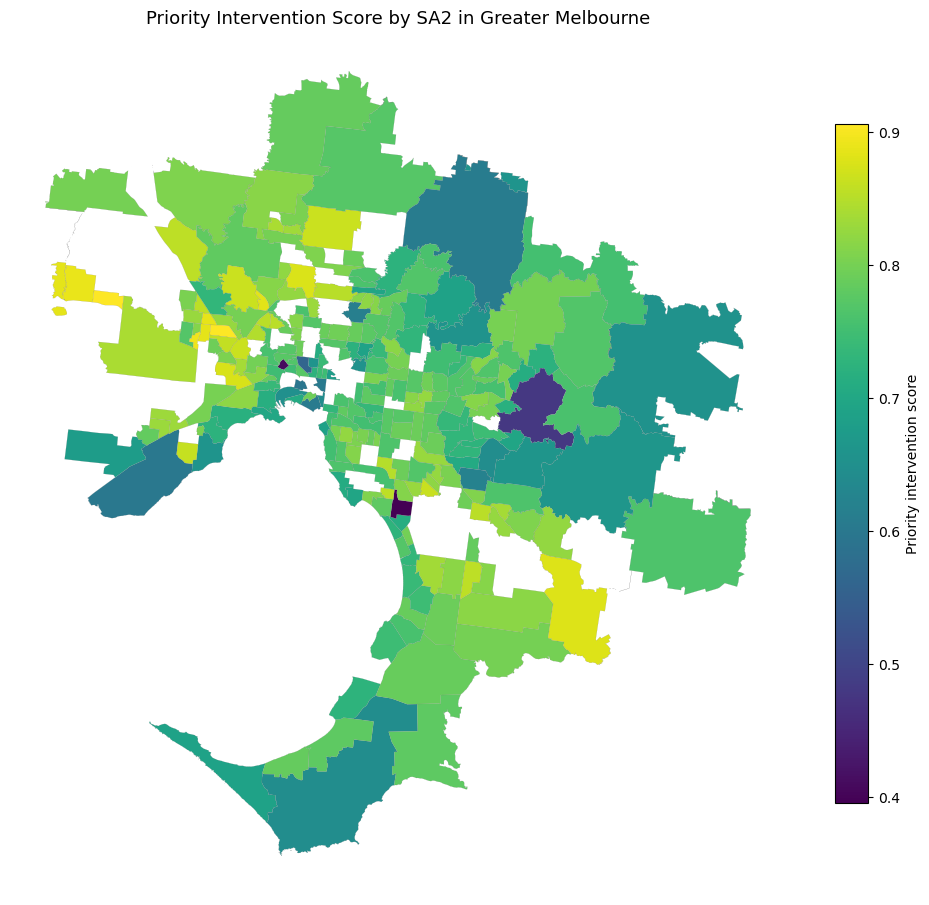

In [56]:
# Map the priority intervention score

fig, ax = plt.subplots(figsize=(10, 10))

priority_result.plot(
    column="priority_score",
    legend=True,
    legend_kwds={
        "label": "Priority intervention score",
        "shrink": 0.7
    },
    edgecolor="grey",
    linewidth=0.1,
    ax=ax
)

ax.set_title(
    "Priority Intervention Score by SA2 in Greater Melbourne",
    fontsize=13
)
ax.axis("off")

fig.tight_layout()
plt.show()


**Figure X. Priority intervention score by SA2 in Greater Melbourne.**  
Higher values indicate SA2s with higher combined priority based on urban heat intensity, low open space coverage, low green space per person and social vulnerability.

### 8.6 Conclusion

This section developed a simple social vulnerability and priority intervention analysis at the SA2 level. The social vulnerability score was based on median household income, elderly population percentage, children population percentage and population density. These indicators were used to represent socio-economic capacity, heat sensitivity and population exposure.

The final priority intervention score combined social vulnerability with environmental indicators from Q2, including urban heat intensity, open space coverage and green space per person. The results show that priority areas are not only defined by high heat, but by the overlap between heat exposure, limited green space availability and social vulnerability.

This analysis is useful as a first-stage screening tool for urban greening and heat mitigation planning. However, the result should be interpreted carefully because it uses equal weighting, SA2-level data and only the 257 SA2 areas matched in the Q2 dataset. Future analysis could include tree canopy cover, park accessibility, building density and more detailed local-scale demographic data. Green space per person also has some high values in outer SA2 areas, so the standardised score may be affected by outliers.

## 9. Discussion

### 9.1 The Inequality of Green Space Distribution 
The research results indicate that the distribution of green space in the Greater Melbourne area is not balanced. Among the 360 SA2s included in the analysis, the average coverage rate of open space is approximately 17.6%, and the median is about 14.9%. There are significant differences between different regions, with the lowest value approaching 0% and the highest exceeding 80%. Regions with a higher coverage rate of open space include Royal Botanic Gardens Victoria, Flemington Racecourse, Parkville, and Werribee - South. However, the coverage rate of open space is relatively low in some areas around airports, on the urban fringes, and in rapidly developing regions. 

These differences are related to land-use types, development density and the distribution of large parks, protected areas and institutional land. Some SA2s recorded high open space coverage mainly because they contained large parks, racecourses or nature reserves. However, this does not necessarily mean that residents can access and use these green spaces fairly or conveniently. Previous research has also shown that urban green-space benefits are not always equally distributed among different communities (Wolch et al., 2014). Therefore, a higher open space coverage rate does not directly indicate better green space accessibility. 

The per capita green space area provides another perspective for evaluation. Some SA2 areas with a smaller population or mainly non-residential land use, such as Braeside, Flemington Racecourse, and Melbourne Airport, show extremely high per capita green space areas. However, the main reason for these high figures is the relatively small population. 

Therefore, in this study, the open space coverage rate and the per capita green area were used together. The former reflects the proportion of green space in the land area of a region, while the latter reflects the relationship between the green area and the resident population. The comprehensive result of these two factors reflects the accessibility of green space.

### 9.2 The Role of Urban Heat Environment and Green Infrastructure 
The intensity of the urban heat island also exhibits distinct spatial distribution characteristics. The Global Moran's I value is approximately 0.753, and the p-value from the simulation test is 0.001, indicating that the urban heat island has a significant positive spatial clustering feature. The high-temperature areas are often adjacent to other high-temperature areas rather than being randomly distributed throughout the Melbourne metropolitan area. Some SA2s with higher heat island intensity, such as Burnside Heights, Cranbourne, Sydenham, Cairnlea, Melton West and Delahey, are mainly located in the urban periphery or rapidly developing suburbs. 

However, from a global statistical perspective, the relationship between green space indicators and urban heat islands is relatively weak. The (R^2) value of the OLS model is approximately 0.002. Neither the open space coverage rate nor the tree density shows a significant statistical relationship. After grouping by open space coverage rate and tree density, the average heat island intensity of each group did not show a stable and continuous downward trend. 

This result does not mean that green infrastructure has no cooling effect. Previous studies have shown that urban vegetation and parks can reduce local temperatures, although the magnitude of cooling varies according to vegetation type, spatial scale, climatic conditions and surrounding urban form (Bowler et al., 2010; Norton et al., 2015). Instead, the result indicates that green space quantity alone cannot explain differences in the thermal environment across Greater Melbourne.

The actual cooling capacity of different open spaces may vary considerably. For example, an open space may contain extensive tree canopy and irrigated vegetation, or it may consist mainly of dry grassland, bare surfaces or exposed sports fields. Therefore, even when two areas have similar open space coverage, their actual thermal performance may be very different. Tree canopy and impervious surfaces can also interact differently across spatial scales, producing different temperature outcomes (Ziter et al., 2019).

In addition, the urban heat environment is also influenced by factors such as building density, impervious surfaces, industrial land, road networks, surface materials, terrain height, and coastal distance. Therefore, in this study, the open space coverage rate or tree density cannot alone explain the formation of the urban heat island. 

The GWR model further reveals this spatial difference. The (R^2) value of the GWR model is approximately 0.325, and the adjusted (R^2) value is approximately 0.299, which is significantly higher than the 0.002 of the global model. At the same time, the AICc has decreased from approximately 1046 to approximately 959.6. This indicates that compared to using a unified global relationship, the spatial model that allows different regions to have different local relationships can better explain the differences in the urban thermal environment. The local regression coefficients for tree density were relatively small, but most were negative, indicating that the cooling relationship between tree density and urban heat was more consistent. Research conducted in Melbourne has similarly shown that the cooling and thermal-comfort benefits of street trees depend on canopy cover, street geometry and local environmental conditions (Coutts et al., 2016). These results suggest that improving tree canopy coverage, shade and vegetation quality may be more important for urban cooling than simply increasing the total area of open space.
### 9.3 Social Vulnerability and Priority Intervention Areas 
The social vulnerability index considered median household income, the proportion of elderly residents, the proportion of children and population density. These indicators reflect differences in residents’ economic capacity to adapt, their sensitivity to extreme heat and the number of people potentially exposed. The use of socioeconomic and demographic indicators is consistent with established social vulnerability research, which examines differences in the ability of communities to prepare for, respond to and recover from environmental hazards (Cutter et al., 2003).

The research results indicate that social vulnerability and environmental unfavorable conditions do not completely overlap. In some areas with high social vulnerability, the green space and thermal environment conditions are at a medium level; while in other areas with high heat island intensity, they do not necessarily have the highest social vulnerability. Therefore, using either environmental indicators or social indicators alone cannot fully identify the areas with higher urban heat risks. 

The final priority intervention index takes into account high heat island intensity, low open space coverage rate, low per capita green area, and high social vulnerability. The SA2s with higher rankings include St Albans - North, Melton, Burnside, Kings Park, Delahey, Melton West, Tullamarine, Bacchus Marsh, Noble Park - West, and Sunshine West. 

These high-priority areas are mostly concentrated in the western and northwestern parts of Melbourne, with a few located in the southeastern part. They often simultaneously face higher heat environment pressure, less green space resources, and higher social vulnerability. For instance, St Albans - North has a high heat island intensity, a low open space coverage rate, and a relatively small per capita green area. Melton, on the other hand, exhibits both high heat environment pressure and high social vulnerability. 

TThese findings indicate that local governments should make decisions according to the specific environmental and social conditions of each area. A uniform greening policy may not respond effectively to the needs of all communities. Areas where environmental pressure and social disadvantage occur together should receive greater priority in planning and investment. This approach is consistent with environmental justice research, which emphasises the fair distribution of urban green-space benefits (Wolch et al., 2014).

## 10. Limitations

This study takes SA2 as the analytical unit, which is suitable for comparing urban areas, but it may mask the local differences within the regions. The final analysis only includes 257 SA2s, so the results cannot fully represent the entire Greater Melbourne area. 

The coverage rate of open spaces and the per capita green area mainly reflect the quantity of green spaces, but they cannot fully demonstrate the quality, accessibility and actual usage of the green areas. The density of trees also cannot directly reflect the canopy area, shading effect and the condition of the trees. 

In addition, the urban thermal environment is also influenced by factors such as building density, impervious surfaces, transportation, topography and coastal distance. This study can only indicate the correlations between variables, but cannot prove causal relationships. 

Finally, the social vulnerability and priority intervention indices were calculated using equal weights and Min-Max standardisation. Composite vulnerability indices can be sensitive to the selection of variables, spatial scale and calculation method, meaning that different weighting choices may change the final rankings (Schmidtlein et al., 2008). Green space per capita may also be unusually high in areas with very small residential populations. Future research could improve the reliability of the results by using more detailed spatial data and conducting sensitivity analyses.

## 11. Sustainability and Resilience Recommendations

The planning department should give priority to conducting analyses on high-priority SA2 areas, especially in the western and northwestern parts of Melbourne. Further analysis should identify the streets, schools, transportation hubs, activity centers and residential areas with the most severe exposure to high temperatures. 

Urban greening should not focus only on increasing the total area of open space. Greater attention should be given to tree canopy coverage, shade and vegetation quality. Street trees, continuous shaded walking routes, vegetation around public facilities and connected green corridors can provide more direct cooling benefits in heat-exposed areas. The selection and location of green infrastructure should respond to local urban form, climate and heat exposure (Norton et al., 2015).

The existing open spaces also need to enhance their cooling function through quality improvement. For open spaces dominated by dry grasslands or bare surfaces, trees can be planted, the soil's water retention capacity can be improved, local vegetation can be increased, the permeability can be enhanced, and more shading facilities can be set up. 

Green infrastructure should also be combined with other cooling measures, such as cool roofs, high reflectivity materials, permeable pavement, water-sensitive urban design, and shaded bus facilities. These measures are applicable to high-density areas that lack new park space. 

Social equity should be the core principle in the implementation process. Investments should give priority to communities with higher exposure to high temperatures and weaker resident adaptability. At the same time, community participation should be ensured to make the greening projects accessible, culturally appropriate, and in line with the actual needs of local residents. 

In the future, continuous monitoring of tree canopy coverage, surface temperature, green space accessibility, and population changes should also be carried out, so that planning strategies can be adjusted promptly in accordance with new environmental and social conditions.

## 12. Conclusion

This study analyzed the relationship among green spaces, urban heat islands and social equity of residents in the Greater Melbourne region from a spatial perspective. The results showed that there was a clear connection among these three issues, but their spatial relationship was rather complex and there was no single unified model applicable to all regions. 

Firstly, the distribution of green space resources is uneven across the Greater Melbourne area. The coverage rate of open spaces varies from nearly 0% to over 80%, while the per capita green area is significantly influenced by the population size and the type of land use. This indicates that using either the coverage rate of open spaces or the per capita green area alone cannot fully assess the fairness of green space in a region. 
Secondly, the urban heat island phenomenon exhibits a significant spatial clustering characteristic. The Global Moran's I value is approximately 0.753. Regions with high temperatures are usually adjacent to other high-temperature areas, indicating that the urban heat risk has a distinct regional nature. 

However, the global regression results indicate that the explanatory power of open space coverage rate and tree density is relatively weak across the entire Greater Melbourne scale. In contrast, the GWR model has a higher (R^2) and reveals significant spatial differences between different regions. Open space shows a cooling effect in some areas, but the relationship is weaker or even positive in other areas; tree density exhibits a relatively more stable negative relationship. This suggests that the type of green space, vegetation structure, and tree canopy quality may be more important than the area of the green space itself. 

The social vulnerability analysis further indicates that urban heat risks cannot be evaluated solely based on environmental indicators. The areas that require the most attention are those where high temperatures, insufficient green spaces, and social vulnerability overlap. The final priority intervention analysis identified relatively concentrated areas of combined adverse conditions in the western and northwestern parts of Melbourne, including St Albans - North, Melton, Burnside, Kings Park, Delahey, and Melton West. 

Overall, this study answered the core research question: Green spaces, urban heat environment, and social equity of residents are spatially interrelated, but this relationship varies across different regions. Therefore, future urban greening and heat environment management should not adopt a completely uniform policy, but should implement targeted interventions based on the environmental conditions and social needs of different regions. 
The future urban greening strategies should place greater emphasis on tree canopy coverage, green space quality, accessibility, and the thermal adaptability of vulnerable social communities. Although the priority intervention index constructed in this study is still a preliminary screening tool, it can provide valuable spatial basis for identifying areas where environmental improvement and social equity benefits can be achieved simultaneously.

## 13. Referencess

Bowler, D. E., Buyung-Ali, L., Knight, T. M., & Pullin, A. S. (2010). Urban greening to cool towns and cities: A systematic review of the empirical evidence. Landscape and Urban Planning, 97(3), 147–155. https://doi.org/10.1016/j.landurbplan.2010.05.006

Coutts, A. M., White, E. C., Tapper, N. J., Beringer, J., & Livesley, S. J. (2016). Temperature and human thermal comfort effects of street trees across three contrasting street canyon environments. Theoretical and Applied Climatology, 124(1–2), 55–68. https://doi.org/10.1007/s00704-015-1409-y

Cutter, S. L., Boruff, B. J., & Shirley, W. L. (2003). Social vulnerability to environmental hazards. Social Science Quarterly, 84(2), 242–261. https://doi.org/10.1111/1540-6237.8402002

Norton, B. A., Coutts, A. M., Livesley, S. J., Harris, R. J., Hunter, A. M., & Williams, N. S. G. (2015). Planning for cooler cities: A framework to prioritise green infrastructure to mitigate high temperatures in urban landscapes. Landscape and Urban Planning, 134, 127–138. https://doi.org/10.1016/j.landurbplan.2014.10.018

Schmidtlein, M. C., Deutsch, R. C., Piegorsch, W. W., & Cutter, S. L. (2008). A sensitivity analysis of the Social Vulnerability Index. Risk Analysis, 28(4), 1099–1114. https://doi.org/10.1111/j.1539-6924.2008.01072.x

Wolch, J. R., Byrne, J., & Newell, J. P. (2014). Urban green space, public health, and environmental justice: The challenge of making cities “just green enough.” Landscape and Urban Planning, 125, 234–244. https://doi.org/10.1016/j.landurbplan.2014.01.017

Ziter, C. D., Pedersen, E. J., Kucharik, C. J., & Turner, M. G. (2019). Scale-dependent interactions between tree canopy cover and impervious surfaces reduce daytime urban heat during summer. Proceedings of the National Academy of Sciences of the United States of America, 116(15), 7575–7580. https://doi.org/10.1073/pnas.1817561116